In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
data = pd.read_csv("temperature_regulation_smart_manufacturing.csv")
data.head()

,Timestamp,Current Temperature (°C),Setpoint Temperature (°C),Temperature Error (°C),PID Control Output (%),Fuzzy PID Control Output (%),Overshoot (°C),Response Time (s),Steady-State Error (°C),Ambient Temperature (°C),Humidity (%),PID Kp,PID Ki,PID Kd,Fuzzy Rule Base Parameters
0,2025-01-31 12:09:12.524887,368.727006,400,31.272994,67.405317,65.022374,6.727030,47.159876,0.787271,23.944771,50.387995,1.220268,0.465431,0.249456,2
1,2025-01-31 12:14:12.524887,397.535715,400,2.464285,81.676038,79.145826,7.966814,54.162970,0.946871,22.517159,51.867725,1.187283,0.310144,0.233165,0
2,2025-01-31 12:19:12.524887,386.599697,400,13.400303,94.917833,98.980379,2.504679,52.804828,1.709095,24.617184,58.312458,0.595754,0.389964,0.170462,0
3,2025-01-31 12:24:12.524887,379.932924,400,20.067076,89.288995,86.784457,6.248741,34.616997,0.680009,23.839349,57.667684,1.422572,0.274419,0.342907,1
4,2025-01-31 12:29:12.524887,357.800932,400,42.199068,92.262446,89.981943,5.717460,34.477484,1.739299,22.471612,53.506427,1.068472,0.352014,0.290650,2


In [98]:
data.describe()

,Current Temperature (°C),Setpoint Temperature (°C),Temperature Error (°C),PID Control Output (%),Fuzzy PID Control Output (%),Overshoot (°C),Response Time (s),Steady-State Error (°C),Ambient Temperature (°C),Humidity (%),PID Kp,PID Ki,PID Kd,Fuzzy Rule Base Parameters
count,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,374.512828,400.0,25.487172,80.280692,80.304749,4.903750,44.823160,0.996929,23.479927,54.823706,0.986497,0.298718,0.302277,1.040000
std,14.606868,0.0,14.606868,11.687596,12.120289,2.864893,8.604298,0.578390,0.869201,2.849144,0.282235,0.112861,0.114581,0.817966
min,350.231601,400.0,0.014116,60.128731,55.847321,0.006534,30.000922,0.012368,22.004285,50.002410,0.500243,0.100021,0.100377,0.000000
25%,361.798663,400.0,12.784021,69.642971,69.714277,2.419008,37.349220,0.498760,22.720665,52.359893,0.749384,0.205658,0.201052,0.000000
50%,374.840369,400.0,25.159631,80.749356,81.088329,4.842793,44.837943,0.980806,23.453929,54.839907,0.978701,0.298075,0.302546,1.000000
75%,387.215979,400.0,38.201337,90.418602,89.969080,7.375408,52.199804,1.479704,24.269393,57.144663,1.215905,0.394487,0.402681,2.000000
max,399.985884,400.0,49.768399,99.976549,104.207067,9.995577,59.932482,1.998701,24.998382,59.989047,1.496013,0.499802,0.499869,2.000000


In [99]:
# Convert to relative time measurement from the t0, format YYYY-MM-DD HH:mm:ss.######
data["Timestamp"] = pd.to_datetime(
    data["Timestamp"],
    format="%Y-%m-%d %H:%M:%S.%f"
)
data = data.sort_values(['Timestamp'])

t0 = data["Timestamp"].iloc[0]
data["Time Seconds"] = (data["Timestamp"] - t0).dt.total_seconds().astype(int)

data.head(10)

,Timestamp,Current Temperature (°C),Setpoint Temperature (°C),Temperature Error (°C),PID Control Output (%),Fuzzy PID Control Output (%),Overshoot (°C),Response Time (s),Steady-State Error (°C),Ambient Temperature (°C),Humidity (%),PID Kp,PID Ki,PID Kd,Fuzzy Rule Base Parameters,Time Seconds
0,2025-01-31 12:09:12.524887,368.727006,400,31.272994,67.405317,65.022374,6.727030,47.159876,0.787271,23.944771,50.387995,1.220268,0.465431,0.249456,2,0
1,2025-01-31 12:14:12.524887,397.535715,400,2.464285,81.676038,79.145826,7.966814,54.162970,0.946871,22.517159,51.867725,1.187283,0.310144,0.233165,0,300
2,2025-01-31 12:19:12.524887,386.599697,400,13.400303,94.917833,98.980379,2.504679,52.804828,1.709095,24.617184,58.312458,0.595754,0.389964,0.170462,0,600
3,2025-01-31 12:24:12.524887,379.932924,400,20.067076,89.288995,86.784457,6.248741,34.616997,0.680009,23.839349,57.667684,1.422572,0.274419,0.342907,1,900
4,2025-01-31 12:29:12.524887,357.800932,400,42.199068,92.262446,89.981943,5.717460,34.477484,1.739299,22.471612,53.506427,1.068472,0.352014,0.290650,2,1200
5,2025-01-31 12:34:12.524887,357.799726,400,42.200274,86.351335,88.945317,8.328304,38.045231,0.176269,24.887014,53.768106,0.863726,0.236230,0.446280,2,1500
6,2025-01-31 12:39:12.524887,352.904181,400,47.095819,87.691063,87.188461,9.060871,40.832242,1.553597,23.555096,55.335544,1.256539,0.220464,0.112844,2,1800
7,2025-01-31 12:44:12.524887,393.308807,400,6.691193,93.967826,96.734932,0.121568,42.253667,1.695095,22.218695,50.002410,0.757365,0.331292,0.357547,2,2100
8,2025-01-31 12:49:12.524887,380.055751,400,19.944249,69.986720,65.640382,6.740199,50.390917,0.363635,23.880499,52.412443,1.193510,0.299252,0.405180,2,2400
9,2025-01-31 12:54:12.524887,385.403629,400,14.596371,79.576999,79.452710,0.518358,31.700413,0.860693,22.759597,52.082318,0.539711,0.331815,0.403795,2,2700


In [100]:
print(data["Time Seconds"].diff().value_counts())
print((data["Response Time (s)"] < 300).value_counts())
print((data["Overshoot (°C)"] < 1).value_counts())
print(data["Fuzzy Rule Base Parameters"].value_counts())

Time Seconds
300.0    999
Name: count, dtype: int64
Response Time (s)
True    1000
Name: count, dtype: int64
Overshoot (°C)
False    894
True     106
Name: count, dtype: int64
Fuzzy Rule Base Parameters
2    355
1    330
0    315
Name: count, dtype: int64


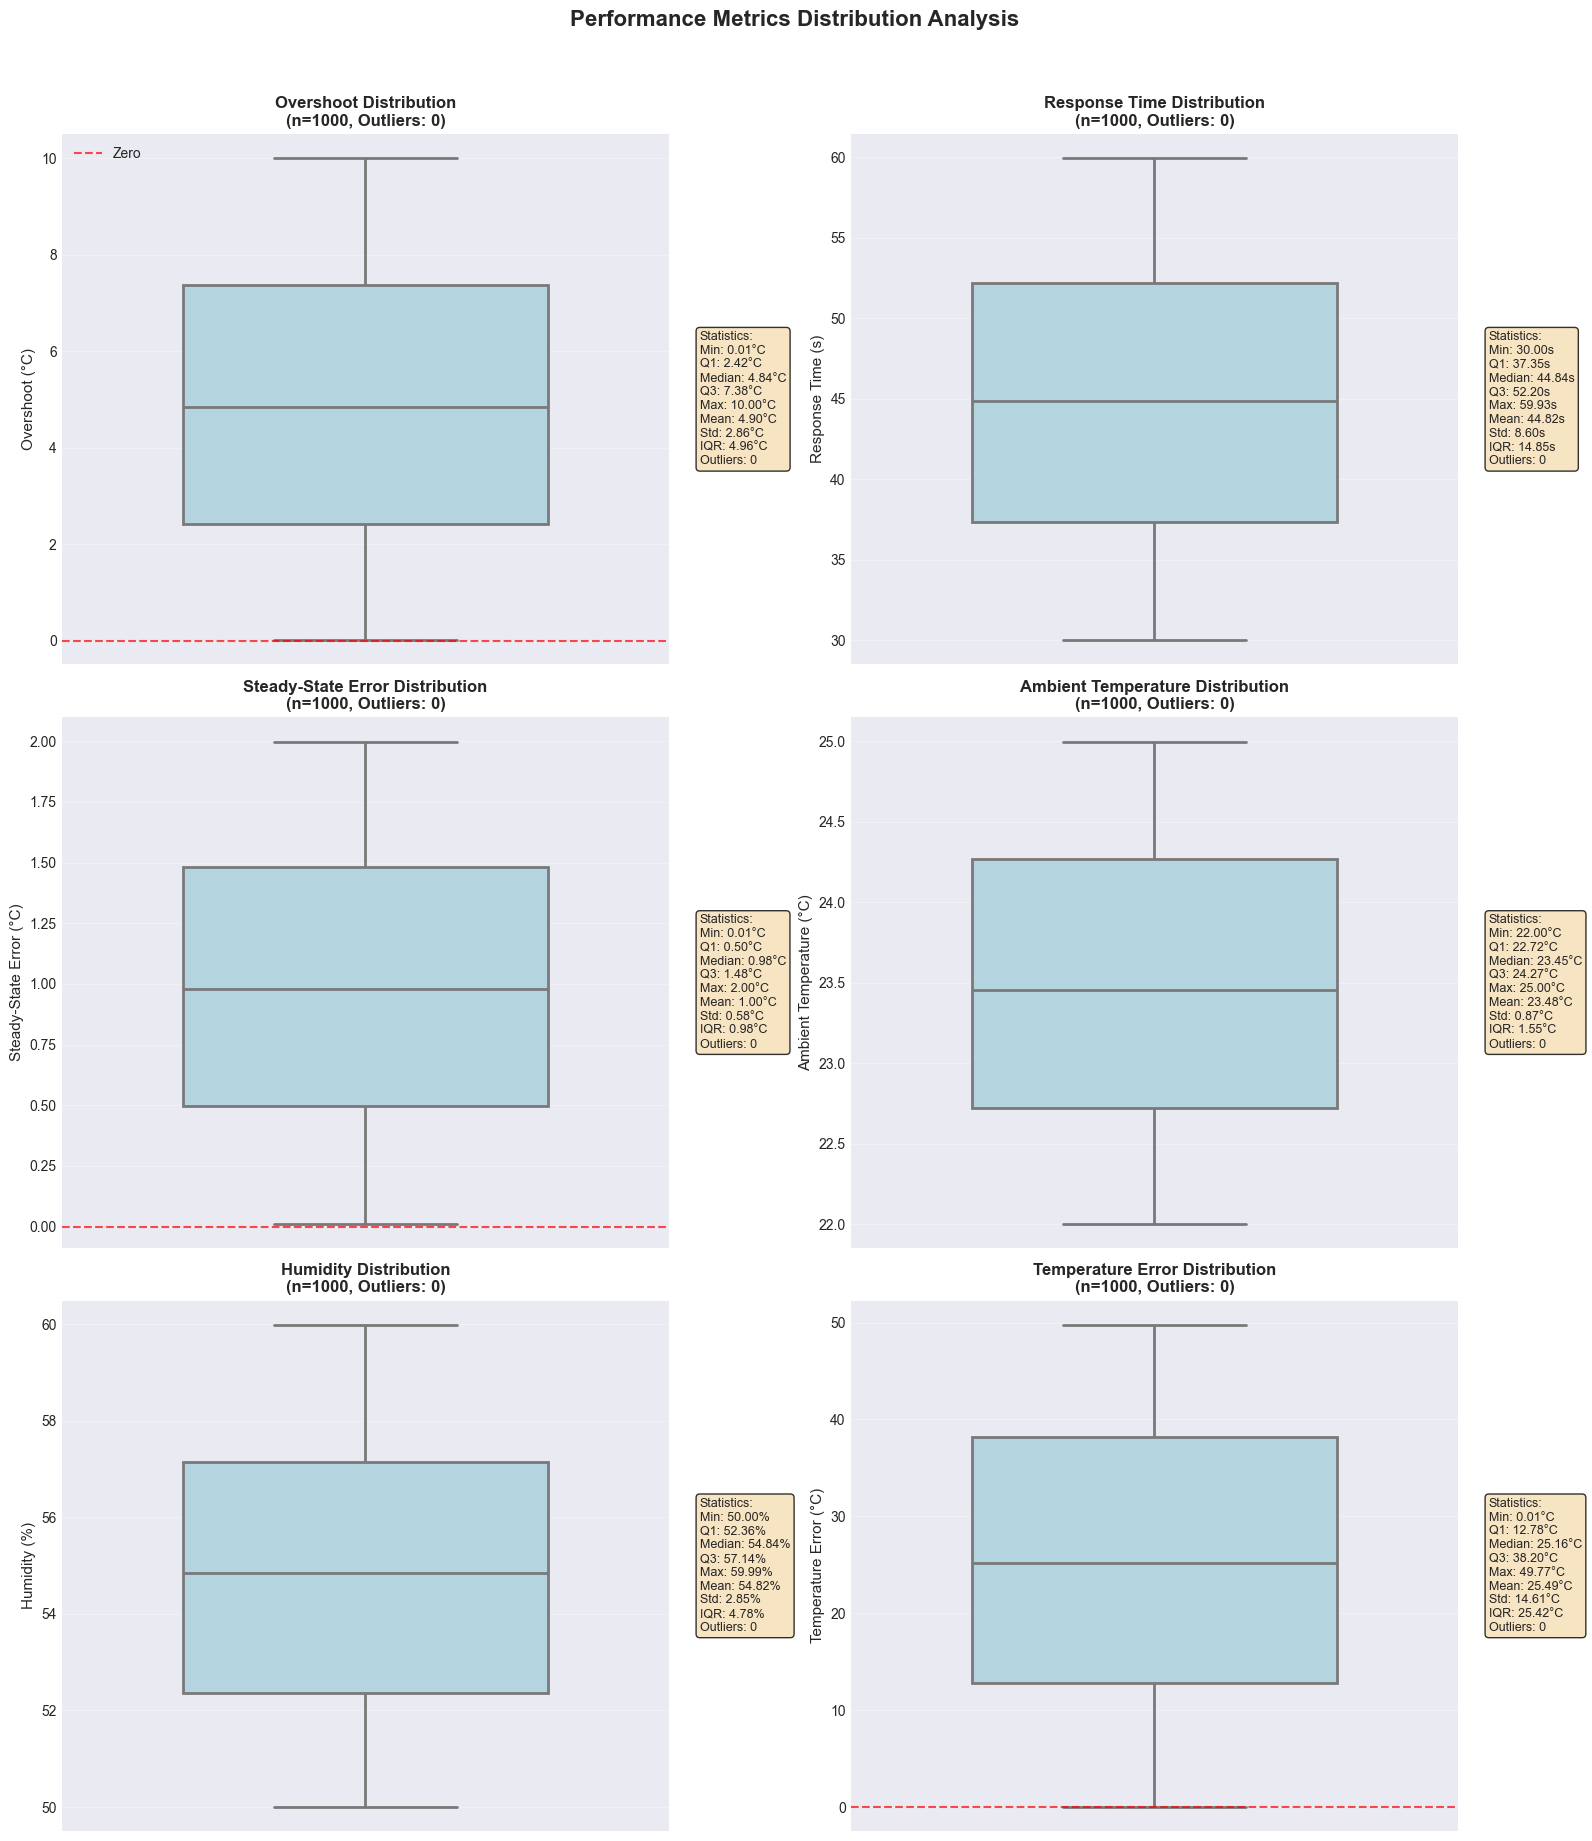

In [101]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))  # Fixed: nrows first, then ncols
axes = axes.flatten()

# Define the keys to plot
keys = ["Overshoot (°C)", "Response Time (s)", "Steady-State Error (°C)", 
        "Ambient Temperature (°C)", "Humidity (%)", "Temperature Error (°C)"]

# Define units for each key (for better labeling)
units = {
    "Overshoot (°C)": "°C",
    "Response Time (s)": "s",
    "Steady-State Error (°C)": "°C",
    "Ambient Temperature (°C)": "°C",
    "Humidity (%)": "%",
    "Temperature Error (°C)": "°C"
}

# Titles for each plot
titles = {
    "Overshoot (°C)": "Overshoot Distribution",
    "Response Time (s)": "Response Time Distribution",
    "Steady-State Error (°C)": "Steady-State Error Distribution",
    "Ambient Temperature (°C)": "Ambient Temperature Distribution",
    "Humidity (%)": "Humidity Distribution",
    "Temperature Error (°C)": "Temperature Error Distribution"
}

for idx, key in enumerate(keys):
    ax = axes[idx]
    
    # Create boxplot with better styling
    # FIXED: Use y parameter for vertical boxplots (more standard)
    bp = sns.boxplot(data=data, y=key, 
                     color='lightblue', 
                     width=0.6,
                     linewidth=2,
                     fliersize=8,
                     flierprops=dict(marker='o', 
                                     markerfacecolor='red', 
                                     markeredgecolor='darkred',
                                     alpha=0.6),
                     ax=ax)
    
    # Calculate and display statistics
    selected_data = data[key].dropna()  # Added dropna to handle missing values
    stats = {
        'Min': selected_data.min(),
        'Q1': selected_data.quantile(0.25),
        'Median': selected_data.median(),
        'Q3': selected_data.quantile(0.75),
        'Max': selected_data.max(),
        'Mean': selected_data.mean(),
        'Std': selected_data.std(),
        'IQR': selected_data.quantile(0.75) - selected_data.quantile(0.25)
    }
    
    # Identify outliers
    Q1 = stats['Q1']
    Q3 = stats['Q3']
    IQR = stats['IQR']
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = selected_data[(selected_data < lower_bound) | (selected_data > upper_bound)]
    
    # Add statistics text (FIXED: transform parameter)
    stats_text = (f"Statistics:\n"
                  f"Min: {stats['Min']:.2f}{units[key]}\n"
                  f"Q1: {stats['Q1']:.2f}{units[key]}\n"
                  f"Median: {stats['Median']:.2f}{units[key]}\n"
                  f"Q3: {stats['Q3']:.2f}{units[key]}\n"
                  f"Max: {stats['Max']:.2f}{units[key]}\n"
                  f"Mean: {stats['Mean']:.2f}{units[key]}\n"
                  f"Std: {stats['Std']:.2f}{units[key]}\n"
                  f"IQR: {stats['IQR']:.2f}{units[key]}\n"
                  f"Outliers: {len(outliers)}")
    
    ax.text(1.05, 0.5, stats_text, transform=ax.transAxes,  # FIXED: transform parameter
            fontsize=9, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Add horizontal line at y=0 for relevant metrics
    # Only add zero line for metrics where zero is meaningful
    if key in ["Overshoot (°C)", "Steady-State Error (°C)", "Temperature Error (°C)"]:
        ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero')
        # Only add legend if we have the zero line
        if idx == 0:  # Add legend only to first relevant plot
            ax.legend(loc='upper left')
    
    # Set title and labels (FIXED: proper title)
    ax.set_title(f'{titles[key]}\n(n={len(selected_data)}, Outliers: {len(outliers)})',
                 fontsize=12, fontweight='bold')
    
    # FIXED: Use ylabel for vertical boxplots
    ax.set_ylabel(f'{key}', fontsize=11)
    ax.set_xlabel('')  # Remove x-label for cleaner look
    
    # FIXED: Grid on the correct axis for vertical boxplots
    ax.grid(True, alpha=0.3, axis='y')
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Adjust layout with proper padding
plt.suptitle('Performance Metrics Distribution Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

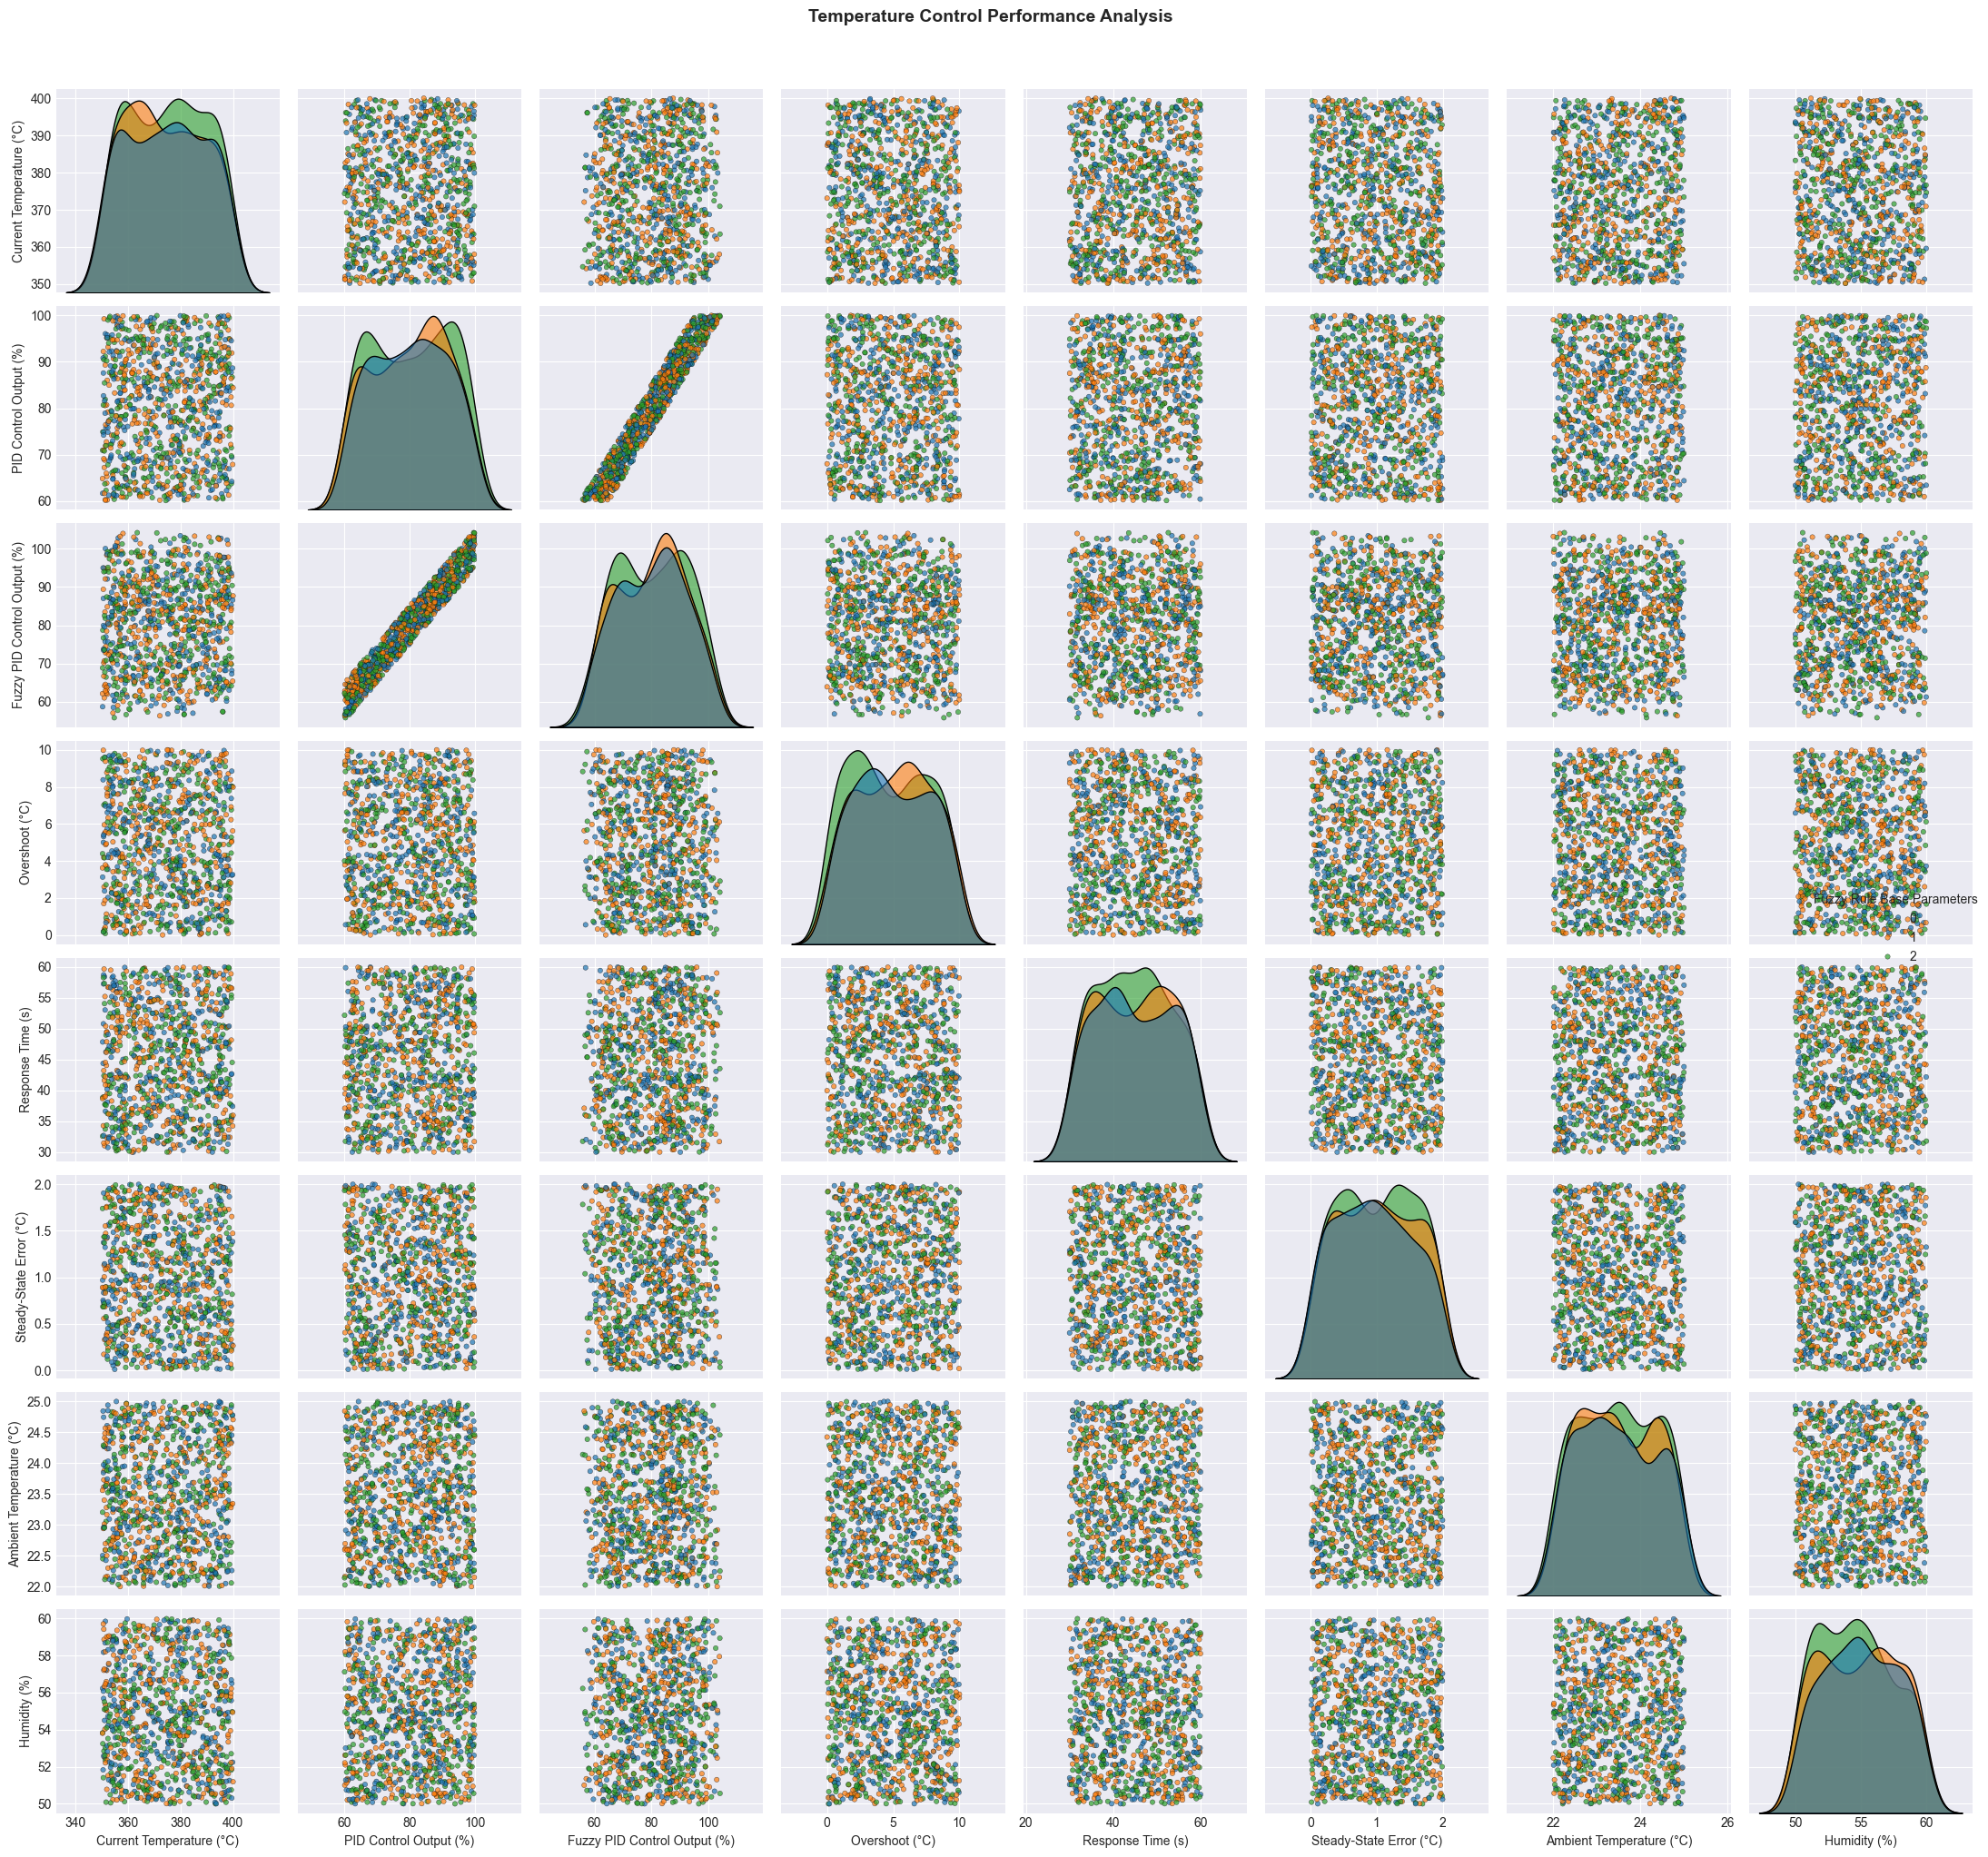

In [102]:
# Select only numeric columns for pairplot (excluding timestamp and text columns)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Or select specific columns
selected_cols = ['Current Temperature (°C)', 'PID Control Output (%)',
       'Fuzzy PID Control Output (%)', 'Overshoot (°C)', 'Response Time (s)',
       'Steady-State Error (°C)', 'Ambient Temperature (°C)', 'Humidity (%)']

sns.pairplot(
    data=data[selected_cols + ["Fuzzy Rule Base Parameters"]],
    hue="Fuzzy Rule Base Parameters",
    palette='tab10',
    plot_kws={'alpha': 0.7, 's': 15, 'edgecolor': 'k', 'linewidth': 0.3},
    diag_kind='auto',
    diag_kws={'alpha': 0.6, 'edgecolor': 'k'}
)
plt.suptitle('Temperature Control Performance Analysis', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

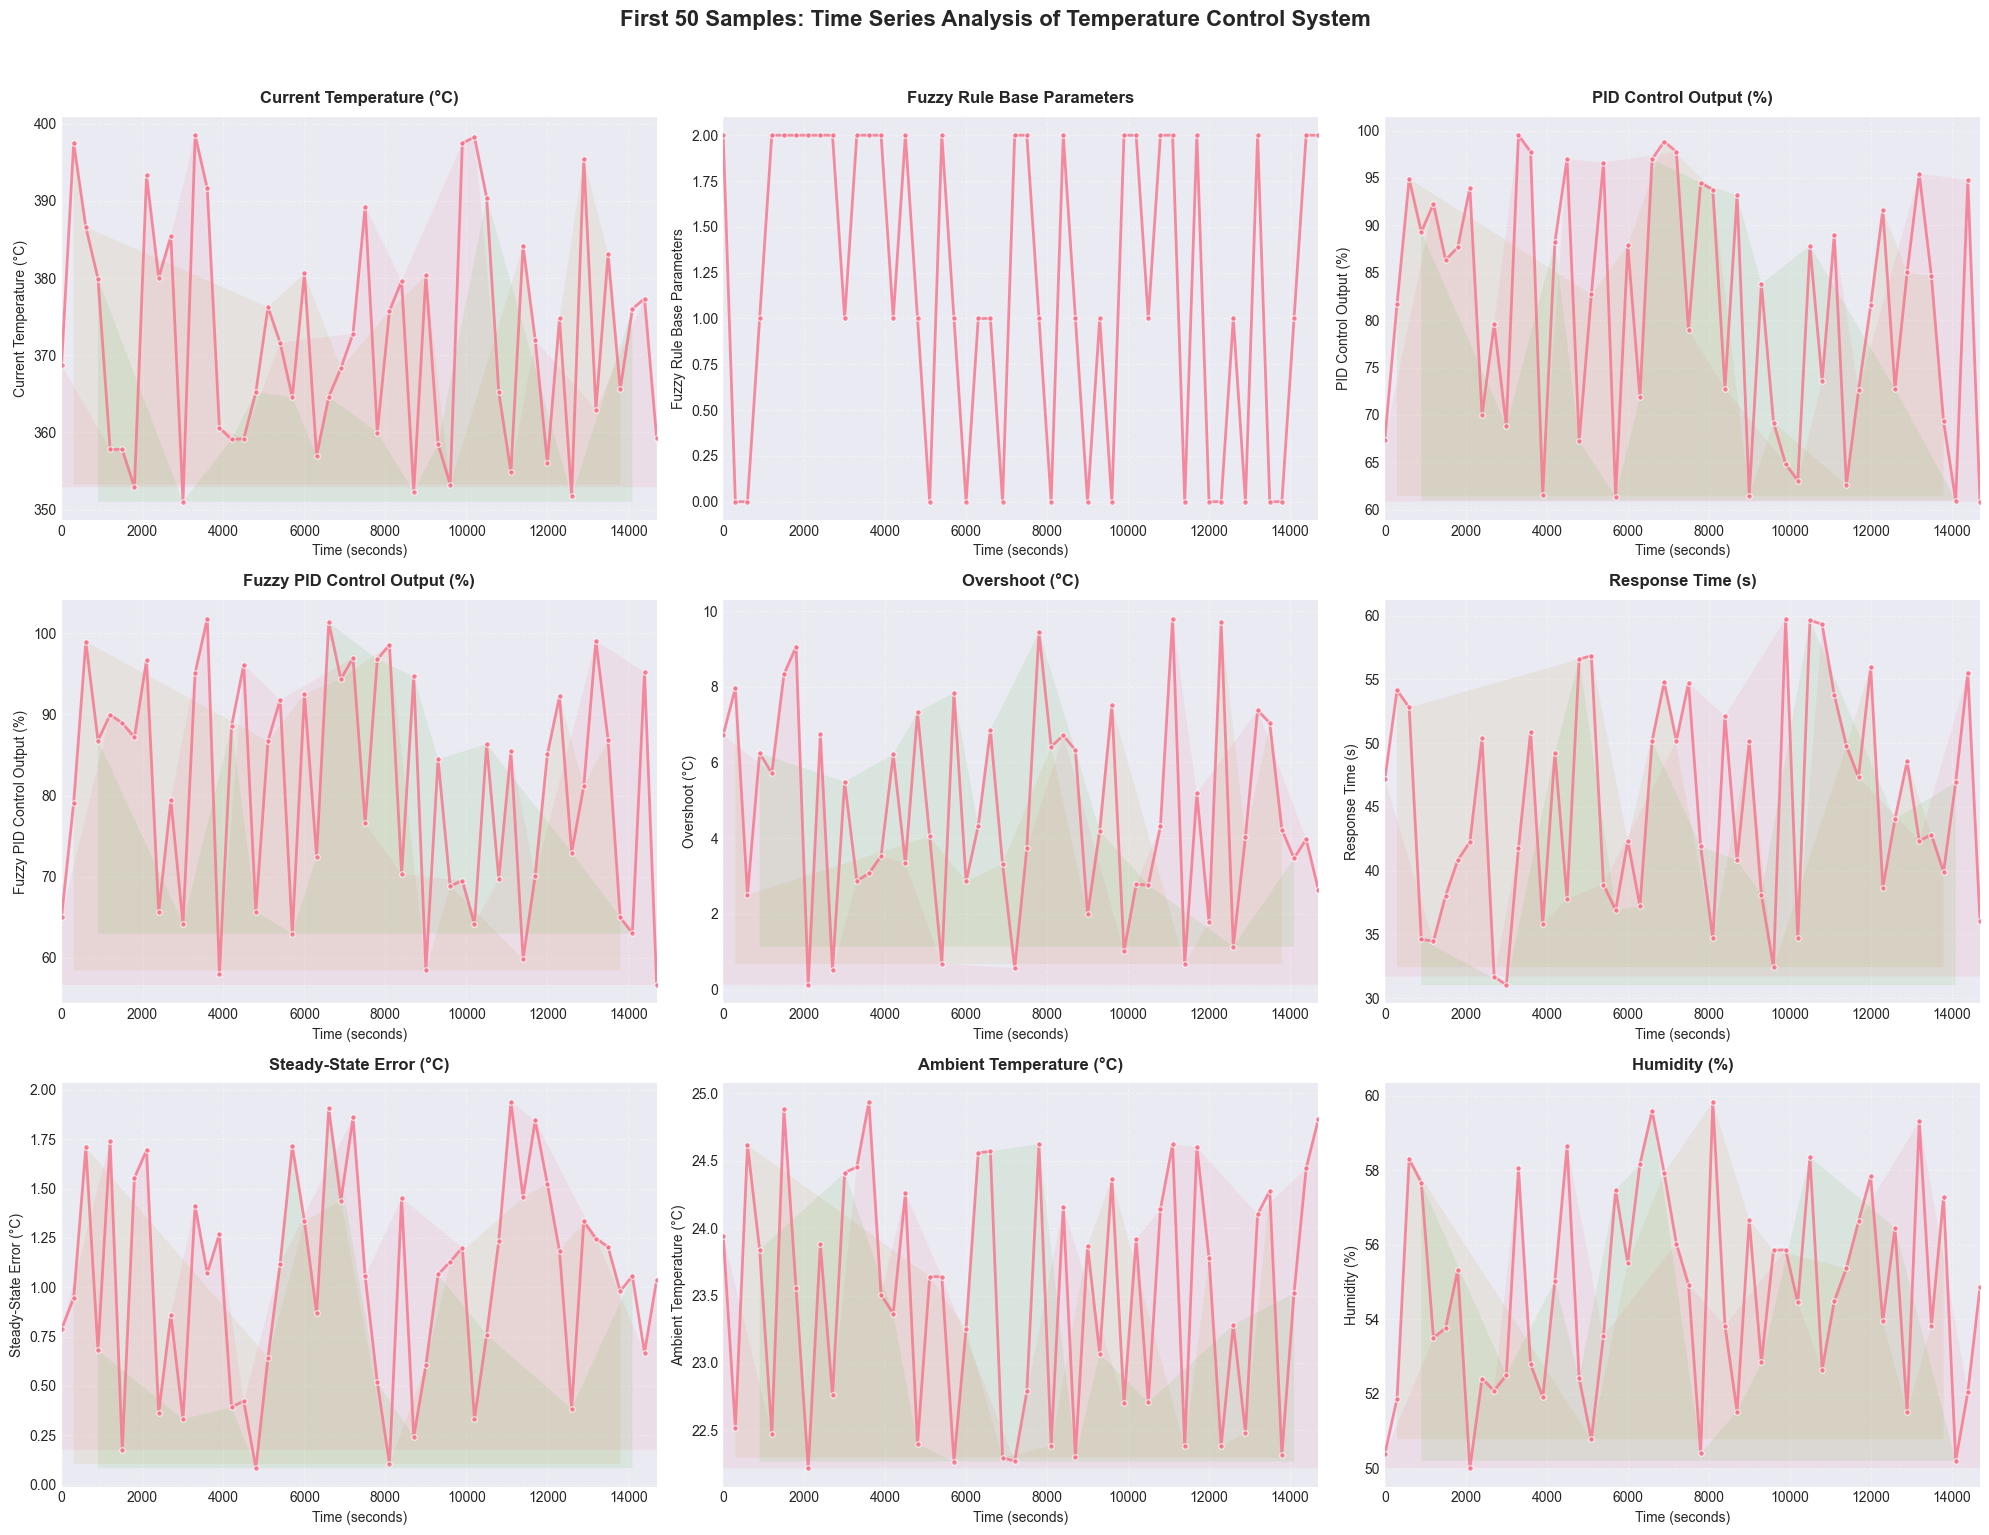

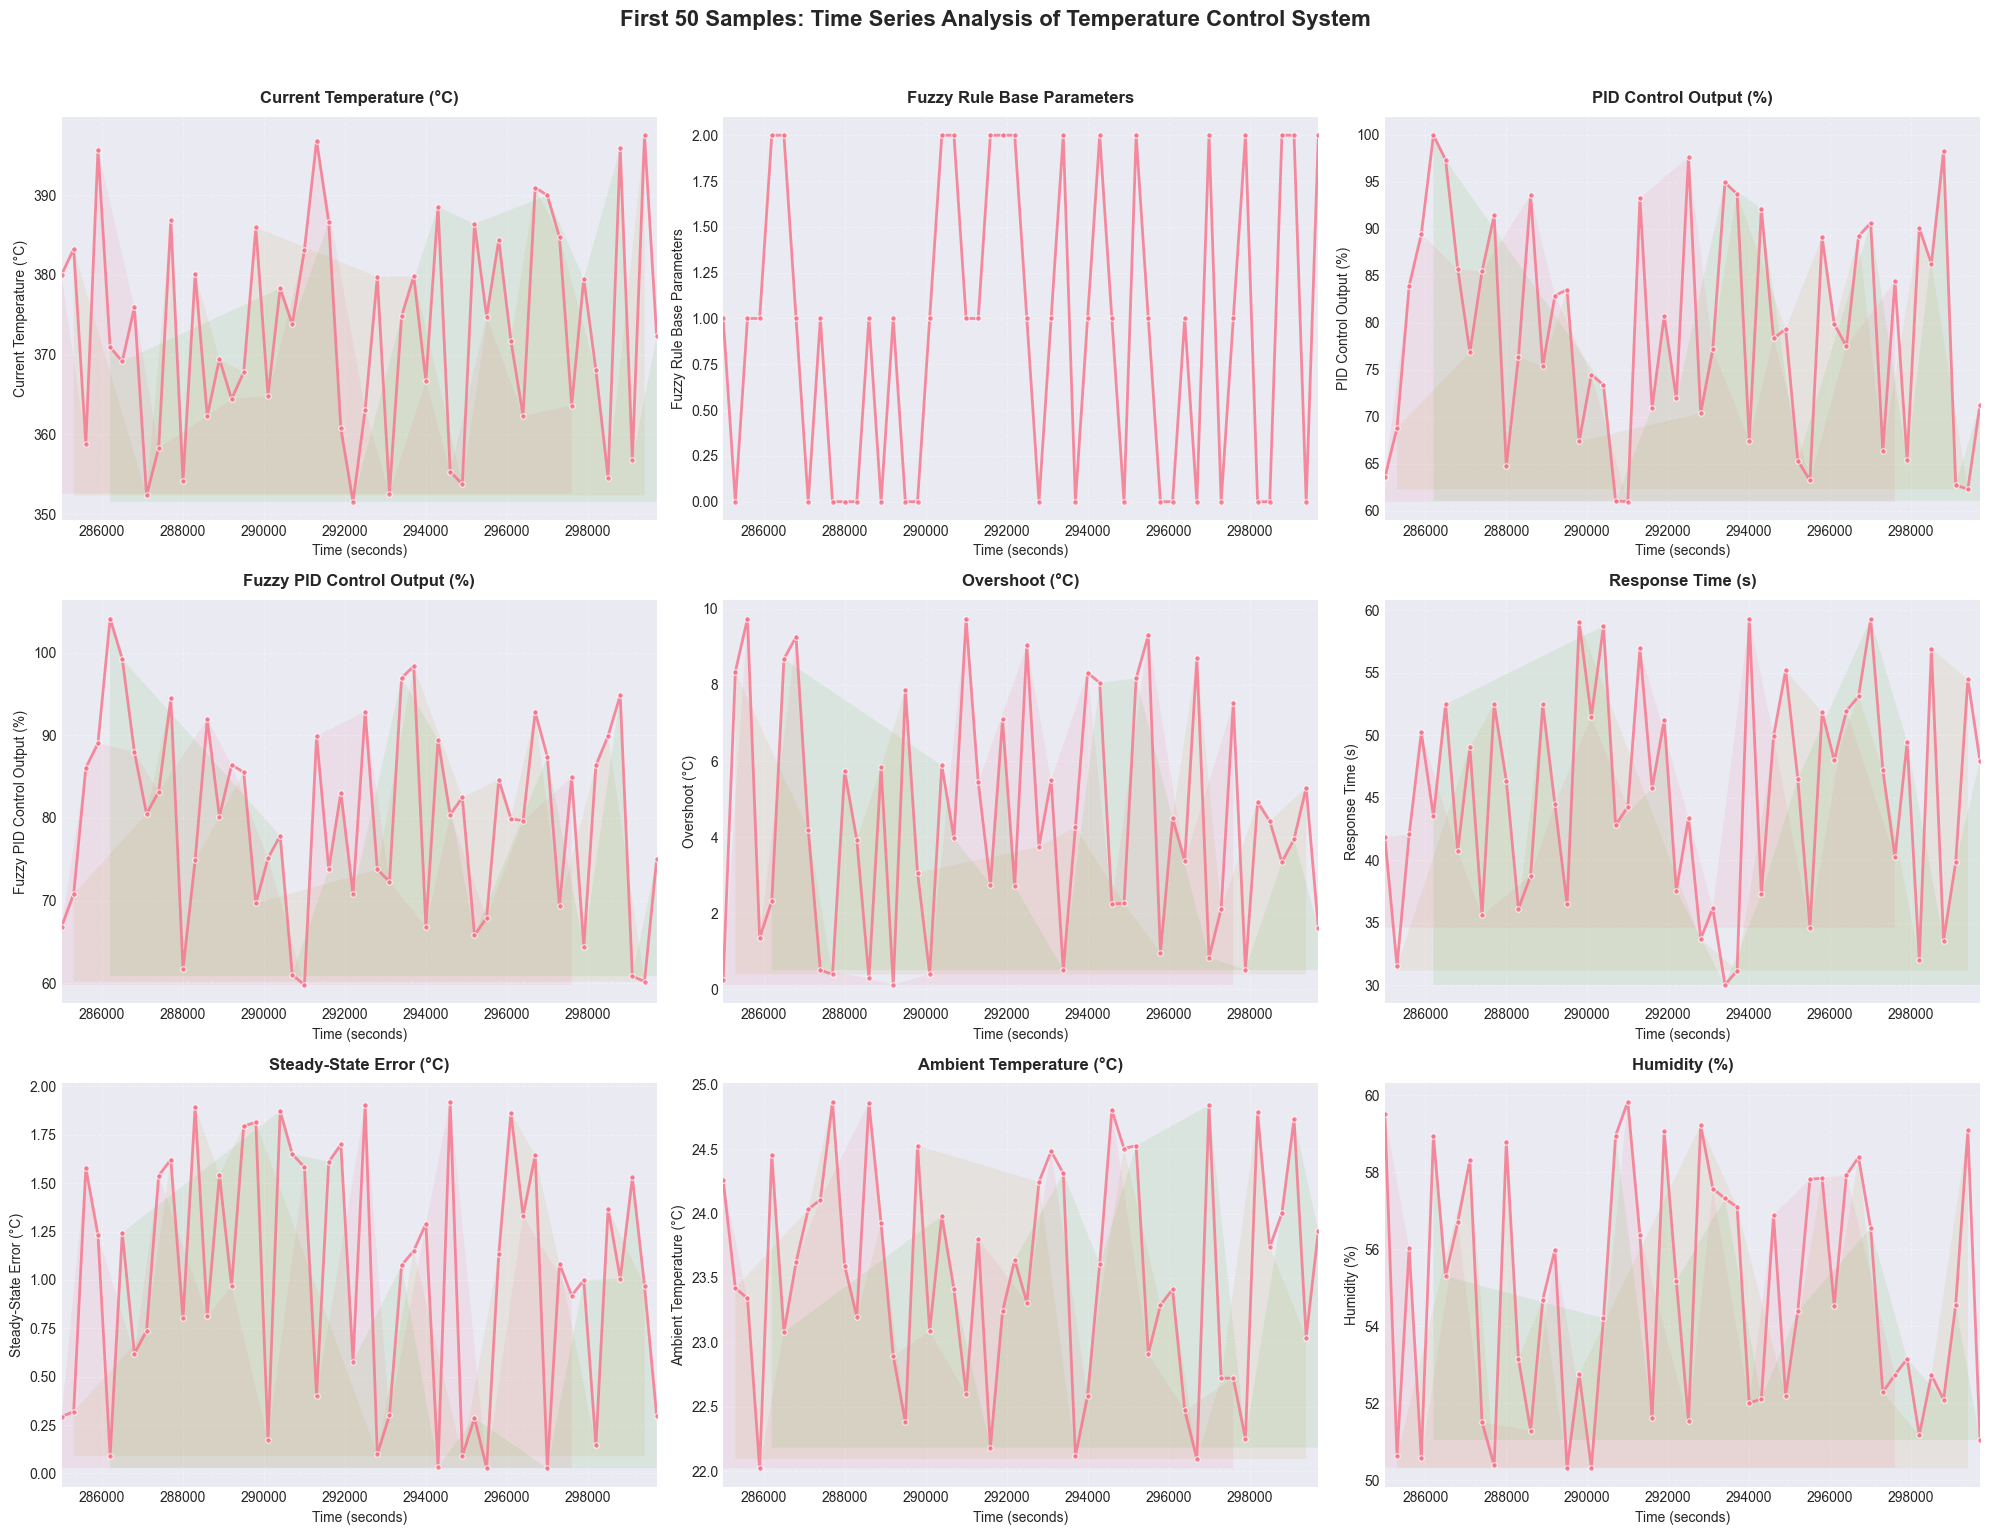

In [103]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Select first 50 samples
selected_data = data.iloc[:50].copy()

# Your selected columns
selected_cols = ['Current Temperature (°C)', 'Fuzzy Rule Base Parameters', 'PID Control Output (%)',
                 'Fuzzy PID Control Output (%)', 'Overshoot (°C)', 'Response Time (s)',
                 'Steady-State Error (°C)', 'Ambient Temperature (°C)', 'Humidity (%)']

# Create figure with better proportions
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

# Add a title to the entire figure
fig.suptitle('First 50 Samples: Time Series Analysis of Temperature Control System', 
             fontsize=16, fontweight='bold', y=1.02)

for idx, col in enumerate(selected_cols):
    ax = axes[idx]
    
    # Create lineplot with better styling
    sns.lineplot(data=selected_data, x='Time Seconds', y=col,
                 ax=ax, 
                 linewidth=2,
                 marker='o',
                 markersize=4,
                 alpha=0.8)
    
    # Customize each subplot
    ax.set_title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Time (seconds)', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    
    # Improve grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Set x-axis limits to show only the 200 samples
    ax.set_xlim(selected_data['Time Seconds'].min(), selected_data['Time Seconds'].max())
    
    # Add fill between lines for better visibility (optional)
    # Get unique control types
    control_types = selected_data['Fuzzy Rule Base Parameters'].unique()
    for control_type in control_types:
        subset = selected_data[selected_data['Fuzzy Rule Base Parameters'] == control_type]
        if len(subset) > 1:
            ax.fill_between(subset['Time Seconds'], subset[col].min(), subset[col], 
                           alpha=0.1)

# Adjust layout
plt.tight_layout()
plt.show()

selected_data = data.iloc[-50:].copy()
# Create figure with better proportions
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

# Add a title to the entire figure
fig.suptitle('First 50 Samples: Time Series Analysis of Temperature Control System', 
             fontsize=16, fontweight='bold', y=1.02)

for idx, col in enumerate(selected_cols):
    ax = axes[idx]
    
    # Create lineplot with better styling
    sns.lineplot(data=selected_data, x='Time Seconds', y=col,
                 ax=ax, 
                 linewidth=2,
                 marker='o',
                 markersize=4,
                 alpha=0.8)
    
    # Customize each subplot
    ax.set_title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Time (seconds)', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    
    # Improve grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Set x-axis limits to show only the 200 samples
    ax.set_xlim(selected_data['Time Seconds'].min(), selected_data['Time Seconds'].max())
    
    # Add fill between lines for better visibility (optional)
    # Get unique control types
    control_types = selected_data['Fuzzy Rule Base Parameters'].unique()
    for control_type in control_types:
        subset = selected_data[selected_data['Fuzzy Rule Base Parameters'] == control_type]
        if len(subset) > 1:
            ax.fill_between(subset['Time Seconds'], subset[col].min(), subset[col], 
                           alpha=0.1)

# Adjust layout
plt.tight_layout()
plt.show()

C:\Users\dangs\AppData\Local\Temp\ipykernel_12872\642730979.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


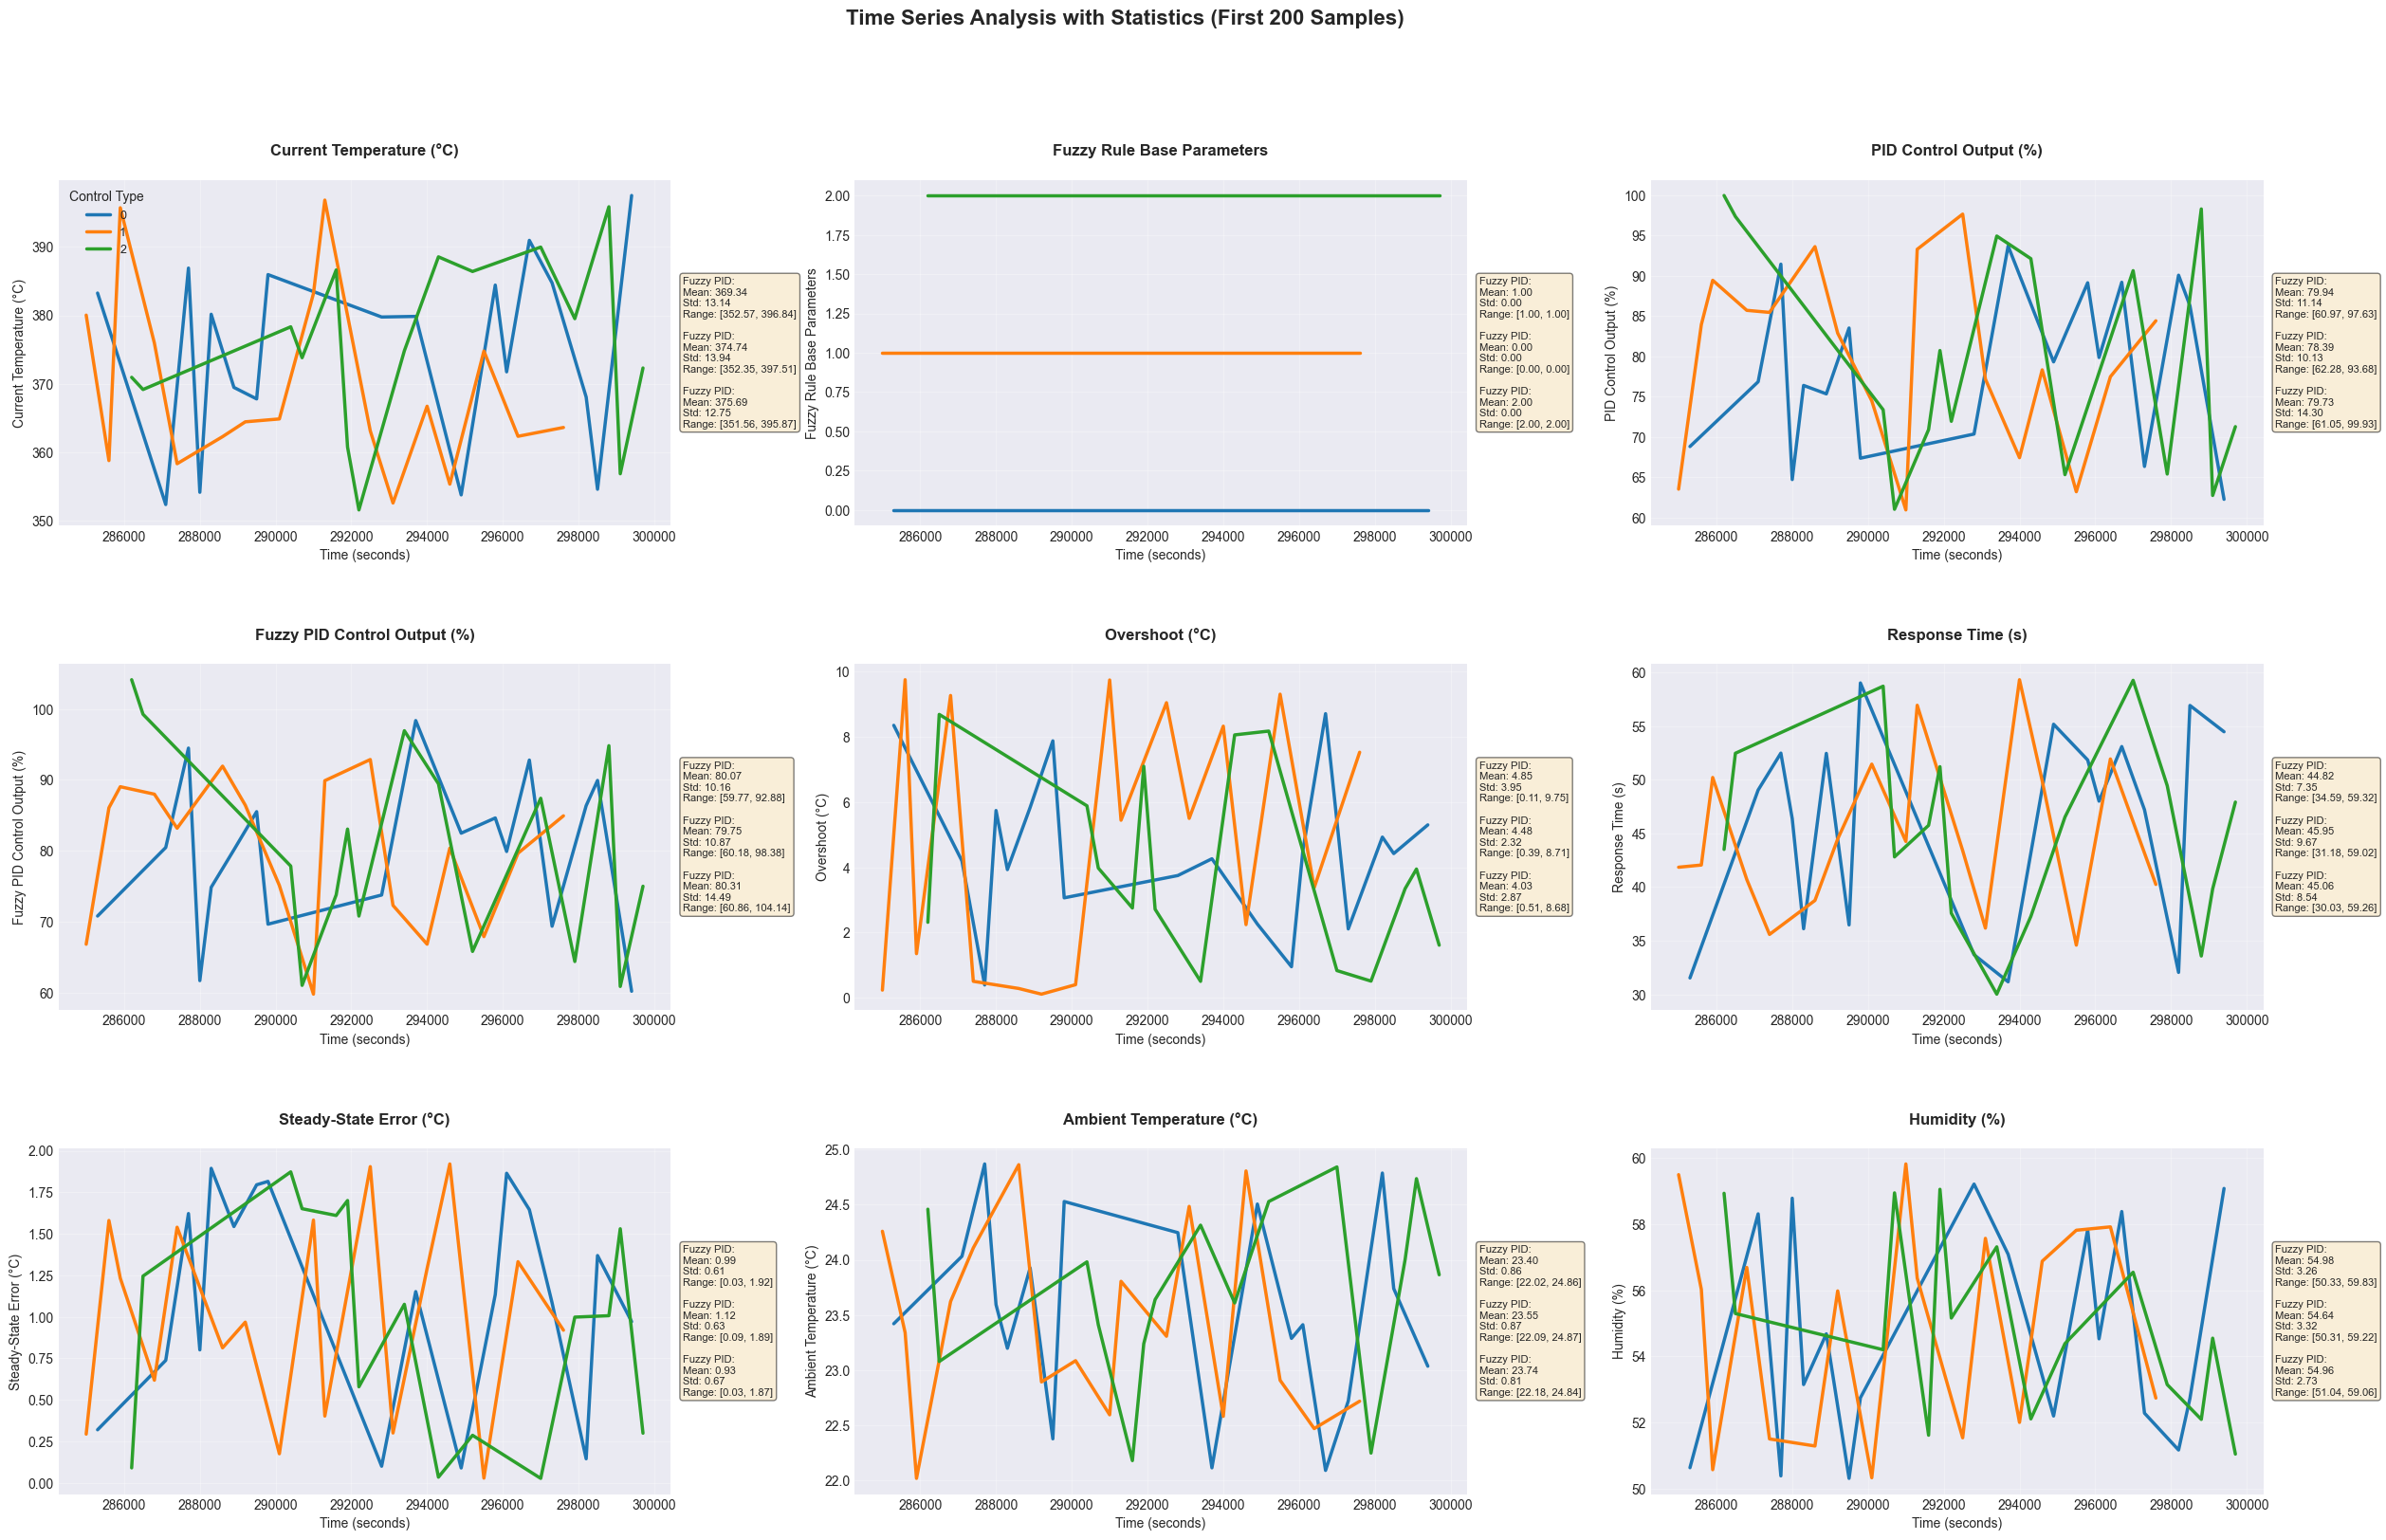

In [104]:
# Create figure with statistics
fig = plt.figure(figsize=(30, 18))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

for idx, col in enumerate(selected_cols):
    # Create main plot
    ax_main = fig.add_subplot(gs[idx])
    
    # Line plot
    sns.lineplot(data=selected_data, x='Time Seconds', y=col, 
                 hue='Fuzzy Rule Base Parameters', 
                 palette='tab10',
                 ax=ax_main, linewidth=2.5)
    
    ax_main.set_title(f'{col}\n', fontsize=12, fontweight='bold')
    ax_main.set_xlabel('Time (seconds)', fontsize=10)
    ax_main.set_ylabel(col, fontsize=10)
    ax_main.grid(True, alpha=0.3)
    
    if idx == 0:
        ax_main.legend(title='Control Type', fontsize=9, title_fontsize=10)
    else:
        ax_main.legend().remove()
    
    # Add statistics box
    stats_text = []
    
    # Calculate statistics for each control type
    control_types = selected_data['Fuzzy Rule Base Parameters'].unique()
    for ctype in control_types:
        subset = selected_data[selected_data['Fuzzy Rule Base Parameters'] == ctype]
        if len(subset) > 0:
            mean_val = subset[col].mean()
            std_val = subset[col].std()
            min_val = subset[col].min()
            max_val = subset[col].max()
            
            ctype_name = 'PID' if pd.isna(ctype) else 'Fuzzy PID'
            stats_text.append(f'{ctype_name}:\n'
                             f'Mean: {mean_val:.2f}\n'
                             f'Std: {std_val:.2f}\n'
                             f'Range: [{min_val:.2f}, {max_val:.2f}]')
    
    # Add statistics annotation
    ax_main.text(1.02, 0.5, '\n\n'.join(stats_text), 
                transform=ax_main.transAxes, fontsize=8,
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Time Series Analysis with Statistics (First 200 Samples)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [105]:
# Test 1: setpoint = temperature + temperature error
# Define tolerance
tolerance = 1e-6

# Create the difference series
diff = data["Setpoint Temperature (°C)"] - data["Current Temperature (°C)"] - data["Temperature Error (°C)"]

# Check which rows satisfy the condition
condition_met = np.abs(diff) < tolerance
# or using np.isclose()
condition_met = np.isclose(diff, 0, atol=tolerance, rtol=0)

print(f"Rows satisfying condition: {condition_met.sum()} out of {len(data)}")
print(f"Percentage: {condition_met.mean() * 100:.2f}%")

Rows satisfying condition: 1000 out of 1000
Percentage: 100.00%


In [106]:
# Test 2: set point = temperature + steady state error
tolerance = 1e-4

# Create the difference series
diff = data["Setpoint Temperature (°C)"] - data["Current Temperature (°C)"] - data["Steady-State Error (°C)"]

# Check which rows satisfy the condition
condition_met = np.abs(diff) < tolerance
# or using np.isclose()
condition_met = np.isclose(diff, 0, atol=tolerance, rtol=0)

print(f"Rows satisfying condition: {condition_met.sum()} out of {len(data)}")
print(f"Percentage: {condition_met.mean() * 100:.2f}%")

Rows satisfying condition: 0 out of 1000
Percentage: 0.00%


In [107]:
data["Final Temperature (°C)"] = data["Setpoint Temperature (°C)"] - data["Steady-State Error (°C)"]
data["Peak Temperature (°C)"] = data["Setpoint Temperature (°C)"] + data["Overshoot (°C)"]
data["Error Rate (°C)"] = data["Temperature Error (°C)"].diff()

Target variable unique values: [2 0 1]
Target variable counts:
Fuzzy Rule Base Parameters
2    355
1    330
0    315
Name: count, dtype: int64

Encoding mapping:
  0 -> 0
  1 -> 1
  2 -> 2

Missing values in features:
Current Temperature (°C)        0
Setpoint Temperature (°C)       0
Temperature Error (°C)          0
PID Control Output (%)          0
Fuzzy PID Control Output (%)    0
Overshoot (°C)                  0
Response Time (s)               0
Steady-State Error (°C)         0
Ambient Temperature (°C)        0
Humidity (%)                    0
PID Kp                          0
PID Ki                          0
PID Kd                          0
Time Seconds                    0
Final Temperature (°C)          0
Peak Temperature (°C)           0
Error Rate (°C)                 1
dtype: int64

Data shape: X = (1000, 17), Y = (1000,)
Classes in Y: [0 1 2]

Training set size: 700 samples
Testing set size: 300 samples


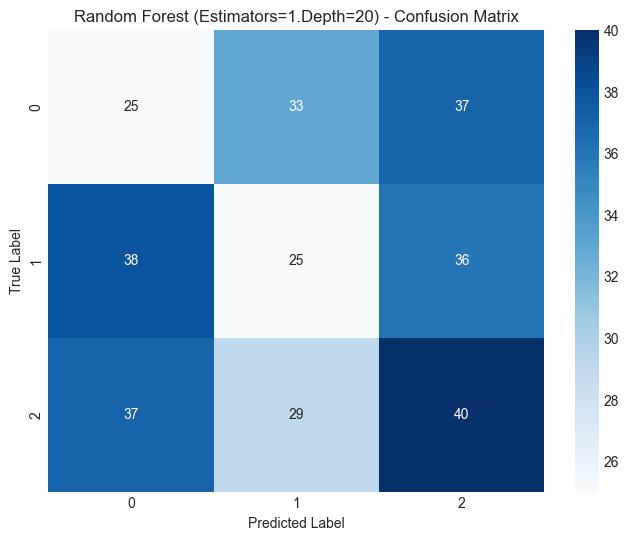

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2977
Specificity (Macro Specificity): 0.6498
F1 Score: 0.2968

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.26      0.26        95
           1       0.29      0.25      0.27        99
           2       0.35      0.38      0.37       106

    accuracy                           0.30       300
   macro avg       0.30      0.30      0.30       300
weighted avg       0.30      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 7.881097349417593
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 2.0642451210372768
 - PID Control Output (%): 7.403925166618391
 - Fuzzy PID Control Output (%): 5.4291177156058685
 - Overshoot (°C): 6.760289253092002
 - Response Time (s): 7.938573259012903
 - Steady-State Error (°C): 4.057004913136226
 - Ambient Temperature (°C): 6.174915896324089
 - Humidity (%): 5.450265156967037
 - PID Kp: 7.921432068369806
 - PID 

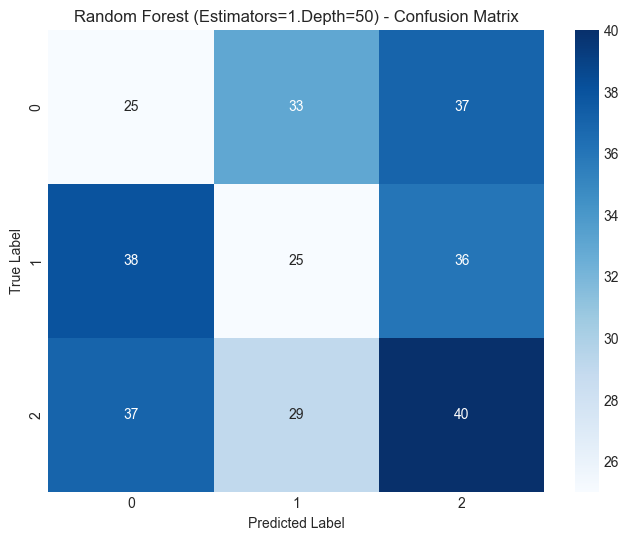

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2977
Specificity (Macro Specificity): 0.6498
F1 Score: 0.2968

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.26      0.26        95
           1       0.29      0.25      0.27        99
           2       0.35      0.38      0.37       106

    accuracy                           0.30       300
   macro avg       0.30      0.30      0.30       300
weighted avg       0.30      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 7.881097349417593
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 2.0642451210372768
 - PID Control Output (%): 7.403925166618391
 - Fuzzy PID Control Output (%): 5.4291177156058685
 - Overshoot (°C): 6.760289253092002
 - Response Time (s): 7.938573259012903
 - Steady-State Error (°C): 4.057004913136226
 - Ambient Temperature (°C): 6.174915896324089
 - Humidity (%): 5.450265156967037
 - PID Kp: 7.921432068369806
 - PID 

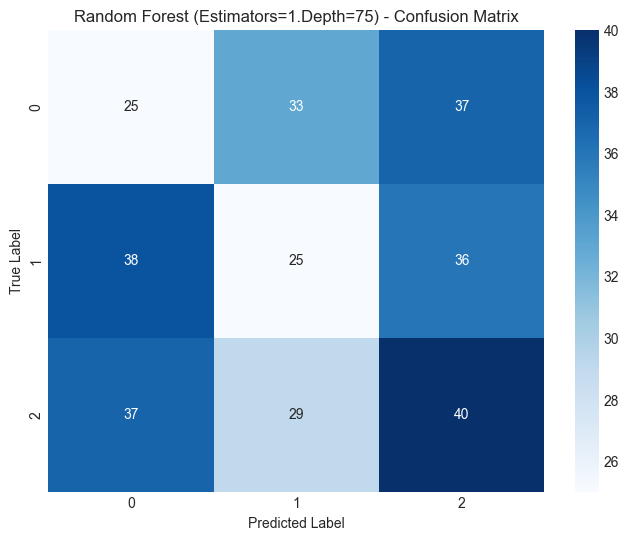

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2977
Specificity (Macro Specificity): 0.6498
F1 Score: 0.2968

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.26      0.26        95
           1       0.29      0.25      0.27        99
           2       0.35      0.38      0.37       106

    accuracy                           0.30       300
   macro avg       0.30      0.30      0.30       300
weighted avg       0.30      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 7.881097349417593
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 2.0642451210372768
 - PID Control Output (%): 7.403925166618391
 - Fuzzy PID Control Output (%): 5.4291177156058685
 - Overshoot (°C): 6.760289253092002
 - Response Time (s): 7.938573259012903
 - Steady-State Error (°C): 4.057004913136226
 - Ambient Temperature (°C): 6.174915896324089
 - Humidity (%): 5.450265156967037
 - PID Kp: 7.921432068369806
 - PID 

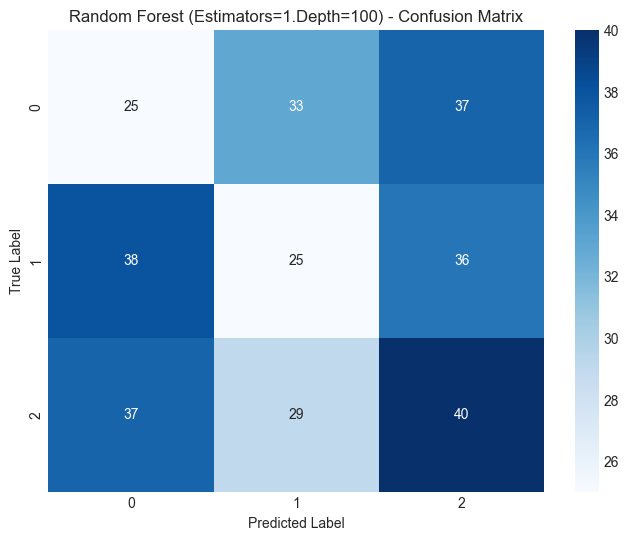

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2977
Specificity (Macro Specificity): 0.6498
F1 Score: 0.2968

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.26      0.26        95
           1       0.29      0.25      0.27        99
           2       0.35      0.38      0.37       106

    accuracy                           0.30       300
   macro avg       0.30      0.30      0.30       300
weighted avg       0.30      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 7.881097349417593
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 2.0642451210372768
 - PID Control Output (%): 7.403925166618391
 - Fuzzy PID Control Output (%): 5.4291177156058685
 - Overshoot (°C): 6.760289253092002
 - Response Time (s): 7.938573259012903
 - Steady-State Error (°C): 4.057004913136226
 - Ambient Temperature (°C): 6.174915896324089
 - Humidity (%): 5.450265156967037
 - PID Kp: 7.921432068369806
 - PID 

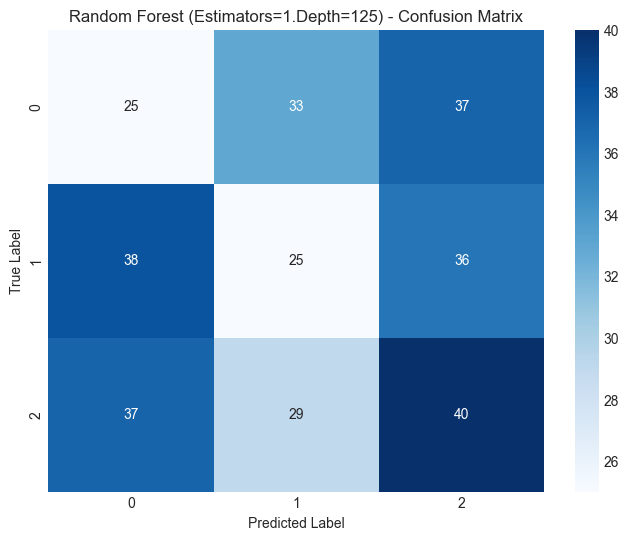

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2977
Specificity (Macro Specificity): 0.6498
F1 Score: 0.2968

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.26      0.26        95
           1       0.29      0.25      0.27        99
           2       0.35      0.38      0.37       106

    accuracy                           0.30       300
   macro avg       0.30      0.30      0.30       300
weighted avg       0.30      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 7.881097349417593
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 2.0642451210372768
 - PID Control Output (%): 7.403925166618391
 - Fuzzy PID Control Output (%): 5.4291177156058685
 - Overshoot (°C): 6.760289253092002
 - Response Time (s): 7.938573259012903
 - Steady-State Error (°C): 4.057004913136226
 - Ambient Temperature (°C): 6.174915896324089
 - Humidity (%): 5.450265156967037
 - PID Kp: 7.921432068369806
 - PID 

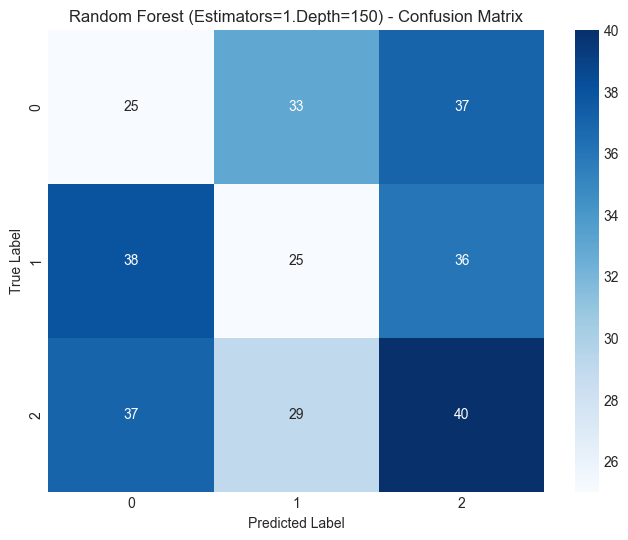

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2977
Specificity (Macro Specificity): 0.6498
F1 Score: 0.2968

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.26      0.26        95
           1       0.29      0.25      0.27        99
           2       0.35      0.38      0.37       106

    accuracy                           0.30       300
   macro avg       0.30      0.30      0.30       300
weighted avg       0.30      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 7.881097349417593
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 2.0642451210372768
 - PID Control Output (%): 7.403925166618391
 - Fuzzy PID Control Output (%): 5.4291177156058685
 - Overshoot (°C): 6.760289253092002
 - Response Time (s): 7.938573259012903
 - Steady-State Error (°C): 4.057004913136226
 - Ambient Temperature (°C): 6.174915896324089
 - Humidity (%): 5.450265156967037
 - PID Kp: 7.921432068369806
 - PID 

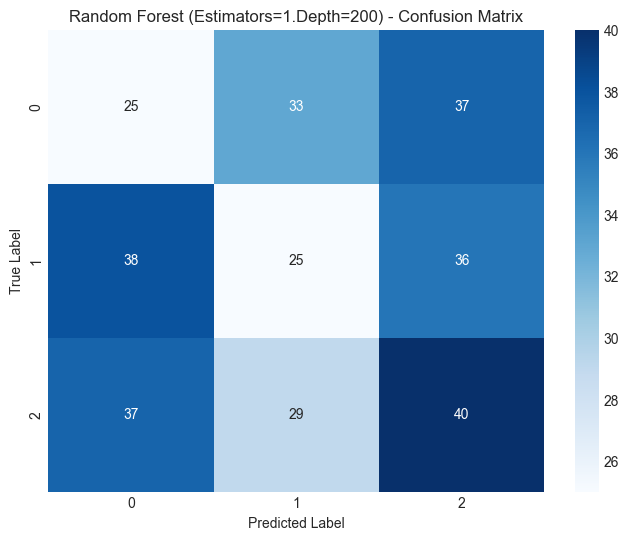

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2977
Specificity (Macro Specificity): 0.6498
F1 Score: 0.2968

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.26      0.26        95
           1       0.29      0.25      0.27        99
           2       0.35      0.38      0.37       106

    accuracy                           0.30       300
   macro avg       0.30      0.30      0.30       300
weighted avg       0.30      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 7.881097349417593
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 2.0642451210372768
 - PID Control Output (%): 7.403925166618391
 - Fuzzy PID Control Output (%): 5.4291177156058685
 - Overshoot (°C): 6.760289253092002
 - Response Time (s): 7.938573259012903
 - Steady-State Error (°C): 4.057004913136226
 - Ambient Temperature (°C): 6.174915896324089
 - Humidity (%): 5.450265156967037
 - PID Kp: 7.921432068369806
 - PID 

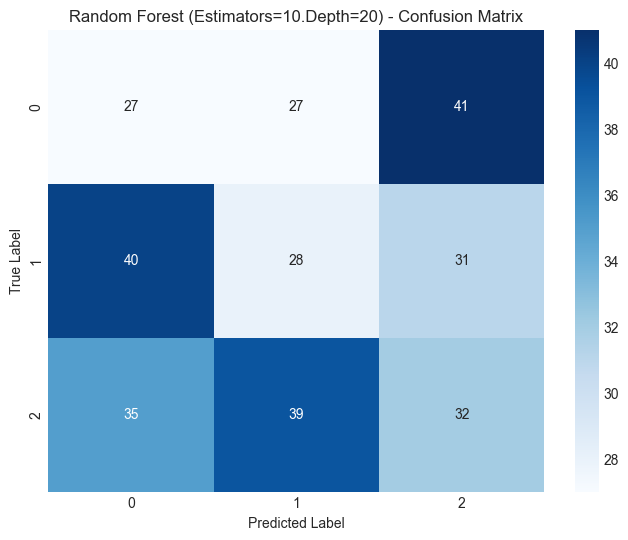

Accuracy: 0.2900
Sensitivity (Macro Recall): 0.2896
Specificity (Macro Specificity): 0.6449
F1 Score: 0.2897

Classification Report:
               precision    recall  f1-score   support

           0       0.26      0.28      0.27        95
           1       0.30      0.28      0.29        99
           2       0.31      0.30      0.30       106

    accuracy                           0.29       300
   macro avg       0.29      0.29      0.29       300
weighted avg       0.29      0.29      0.29       300

Feature Importance:
 - Current Temperature (°C): 6.116506525154687
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 4.805207148911331
 - PID Control Output (%): 6.165646594364628
 - Fuzzy PID Control Output (%): 6.287892464032805
 - Overshoot (°C): 6.736684246015864
 - Response Time (s): 7.849782384894197
 - Steady-State Error (°C): 4.397519296274772
 - Ambient Temperature (°C): 5.803859162720345
 - Humidity (%): 7.889573113033019
 - PID Kp: 7.168694805767663
 - PID Ki

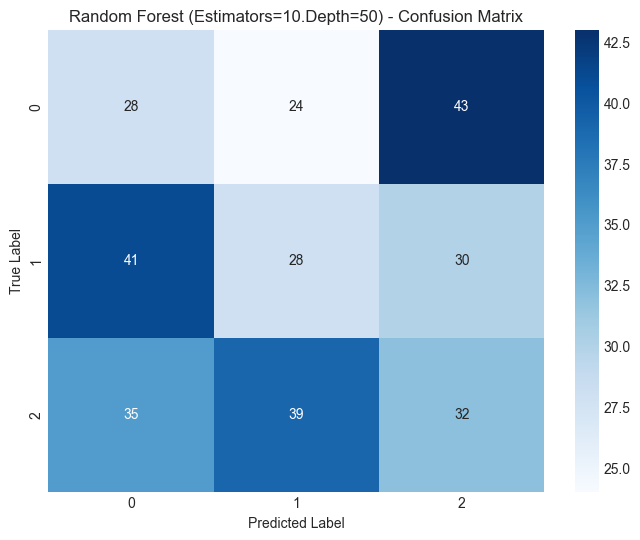

Accuracy: 0.2933
Sensitivity (Macro Recall): 0.2932
Specificity (Macro Specificity): 0.6465
F1 Score: 0.2932

Classification Report:
               precision    recall  f1-score   support

           0       0.27      0.29      0.28        95
           1       0.31      0.28      0.29        99
           2       0.30      0.30      0.30       106

    accuracy                           0.29       300
   macro avg       0.29      0.29      0.29       300
weighted avg       0.29      0.29      0.29       300

Feature Importance:
 - Current Temperature (°C): 6.019938007243004
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 4.409304420218184
 - PID Control Output (%): 6.172338283690125
 - Fuzzy PID Control Output (%): 6.227132575838663
 - Overshoot (°C): 6.496102211937761
 - Response Time (s): 7.634098223379382
 - Steady-State Error (°C): 4.565147683221056
 - Ambient Temperature (°C): 5.981235696146735
 - Humidity (%): 7.915806655244976
 - PID Kp: 7.215466743140164
 - PID Ki

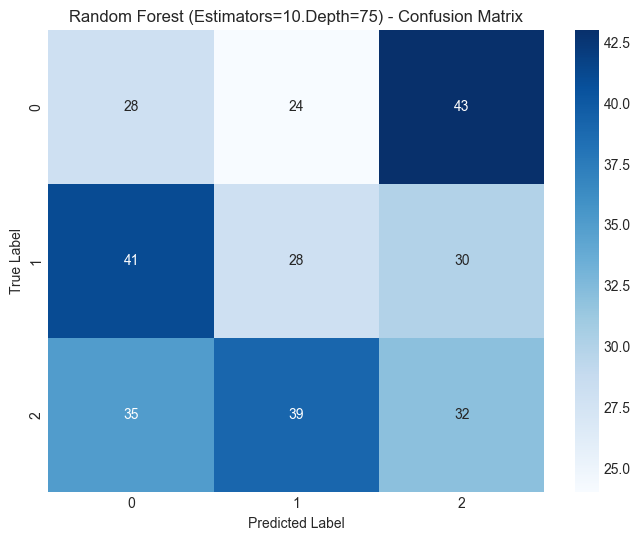

Accuracy: 0.2933
Sensitivity (Macro Recall): 0.2932
Specificity (Macro Specificity): 0.6465
F1 Score: 0.2932

Classification Report:
               precision    recall  f1-score   support

           0       0.27      0.29      0.28        95
           1       0.31      0.28      0.29        99
           2       0.30      0.30      0.30       106

    accuracy                           0.29       300
   macro avg       0.29      0.29      0.29       300
weighted avg       0.29      0.29      0.29       300

Feature Importance:
 - Current Temperature (°C): 6.019938007243004
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 4.409304420218184
 - PID Control Output (%): 6.172338283690125
 - Fuzzy PID Control Output (%): 6.227132575838663
 - Overshoot (°C): 6.496102211937761
 - Response Time (s): 7.634098223379382
 - Steady-State Error (°C): 4.565147683221056
 - Ambient Temperature (°C): 5.981235696146735
 - Humidity (%): 7.915806655244976
 - PID Kp: 7.215466743140164
 - PID Ki

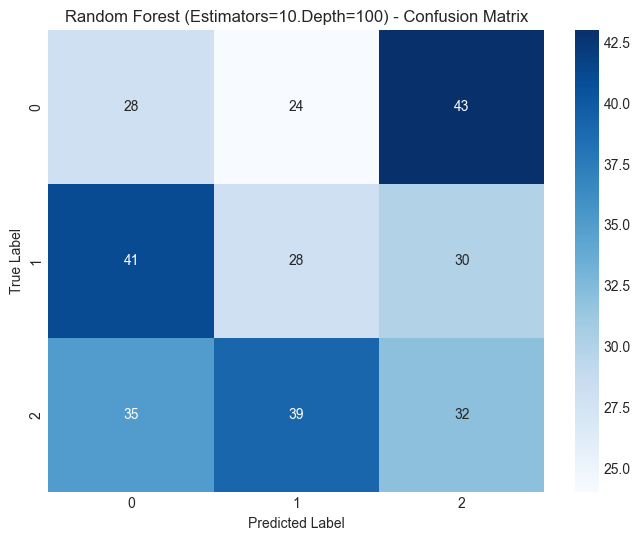

Accuracy: 0.2933
Sensitivity (Macro Recall): 0.2932
Specificity (Macro Specificity): 0.6465
F1 Score: 0.2932

Classification Report:
               precision    recall  f1-score   support

           0       0.27      0.29      0.28        95
           1       0.31      0.28      0.29        99
           2       0.30      0.30      0.30       106

    accuracy                           0.29       300
   macro avg       0.29      0.29      0.29       300
weighted avg       0.29      0.29      0.29       300

Feature Importance:
 - Current Temperature (°C): 6.019938007243004
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 4.409304420218184
 - PID Control Output (%): 6.172338283690125
 - Fuzzy PID Control Output (%): 6.227132575838663
 - Overshoot (°C): 6.496102211937761
 - Response Time (s): 7.634098223379382
 - Steady-State Error (°C): 4.565147683221056
 - Ambient Temperature (°C): 5.981235696146735
 - Humidity (%): 7.915806655244976
 - PID Kp: 7.215466743140164
 - PID Ki

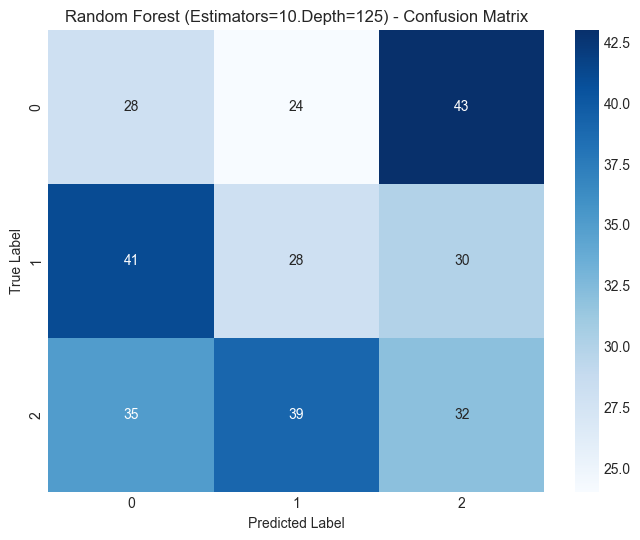

Accuracy: 0.2933
Sensitivity (Macro Recall): 0.2932
Specificity (Macro Specificity): 0.6465
F1 Score: 0.2932

Classification Report:
               precision    recall  f1-score   support

           0       0.27      0.29      0.28        95
           1       0.31      0.28      0.29        99
           2       0.30      0.30      0.30       106

    accuracy                           0.29       300
   macro avg       0.29      0.29      0.29       300
weighted avg       0.29      0.29      0.29       300

Feature Importance:
 - Current Temperature (°C): 6.019938007243004
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 4.409304420218184
 - PID Control Output (%): 6.172338283690125
 - Fuzzy PID Control Output (%): 6.227132575838663
 - Overshoot (°C): 6.496102211937761
 - Response Time (s): 7.634098223379382
 - Steady-State Error (°C): 4.565147683221056
 - Ambient Temperature (°C): 5.981235696146735
 - Humidity (%): 7.915806655244976
 - PID Kp: 7.215466743140164
 - PID Ki

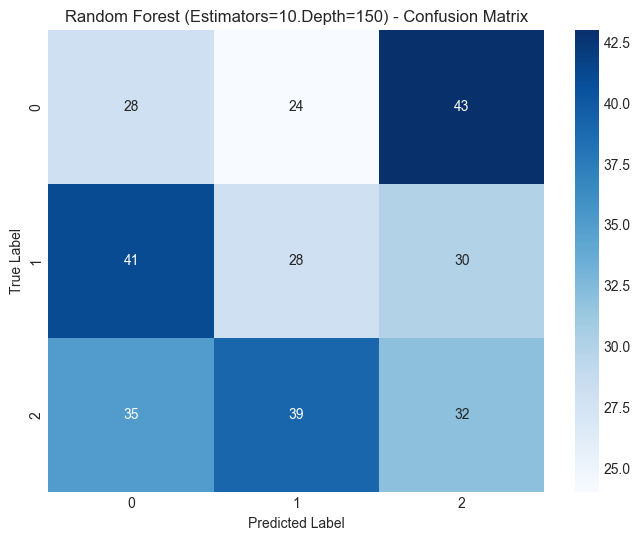

Accuracy: 0.2933
Sensitivity (Macro Recall): 0.2932
Specificity (Macro Specificity): 0.6465
F1 Score: 0.2932

Classification Report:
               precision    recall  f1-score   support

           0       0.27      0.29      0.28        95
           1       0.31      0.28      0.29        99
           2       0.30      0.30      0.30       106

    accuracy                           0.29       300
   macro avg       0.29      0.29      0.29       300
weighted avg       0.29      0.29      0.29       300

Feature Importance:
 - Current Temperature (°C): 6.019938007243004
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 4.409304420218184
 - PID Control Output (%): 6.172338283690125
 - Fuzzy PID Control Output (%): 6.227132575838663
 - Overshoot (°C): 6.496102211937761
 - Response Time (s): 7.634098223379382
 - Steady-State Error (°C): 4.565147683221056
 - Ambient Temperature (°C): 5.981235696146735
 - Humidity (%): 7.915806655244976
 - PID Kp: 7.215466743140164
 - PID Ki

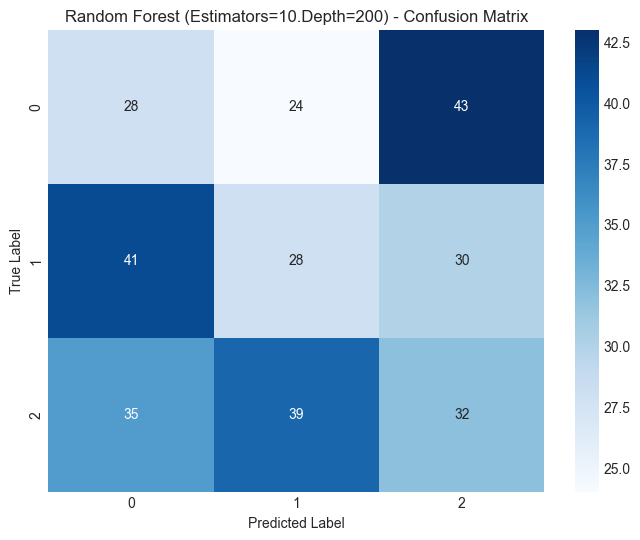

Accuracy: 0.2933
Sensitivity (Macro Recall): 0.2932
Specificity (Macro Specificity): 0.6465
F1 Score: 0.2932

Classification Report:
               precision    recall  f1-score   support

           0       0.27      0.29      0.28        95
           1       0.31      0.28      0.29        99
           2       0.30      0.30      0.30       106

    accuracy                           0.29       300
   macro avg       0.29      0.29      0.29       300
weighted avg       0.29      0.29      0.29       300

Feature Importance:
 - Current Temperature (°C): 6.019938007243004
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 4.409304420218184
 - PID Control Output (%): 6.172338283690125
 - Fuzzy PID Control Output (%): 6.227132575838663
 - Overshoot (°C): 6.496102211937761
 - Response Time (s): 7.634098223379382
 - Steady-State Error (°C): 4.565147683221056
 - Ambient Temperature (°C): 5.981235696146735
 - Humidity (%): 7.915806655244976
 - PID Kp: 7.215466743140164
 - PID Ki

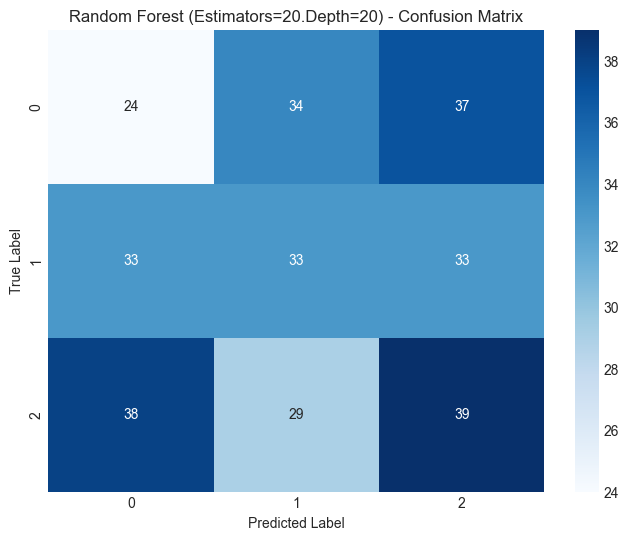

Accuracy: 0.3200
Sensitivity (Macro Recall): 0.3180
Specificity (Macro Specificity): 0.6598
F1 Score: 0.3180

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.25      0.25        95
           1       0.34      0.33      0.34        99
           2       0.36      0.37      0.36       106

    accuracy                           0.32       300
   macro avg       0.32      0.32      0.32       300
weighted avg       0.32      0.32      0.32       300

Feature Importance:
 - Current Temperature (°C): 6.00838654470839
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.651425643283374
 - PID Control Output (%): 6.183839801002092
 - Fuzzy PID Control Output (%): 6.250566014723129
 - Overshoot (°C): 6.211407593470702
 - Response Time (s): 7.357593897218008
 - Steady-State Error (°C): 5.058174284514512
 - Ambient Temperature (°C): 6.087536619640595
 - Humidity (%): 7.364751330223192
 - PID Kp: 6.1661887030730735
 - PID Ki

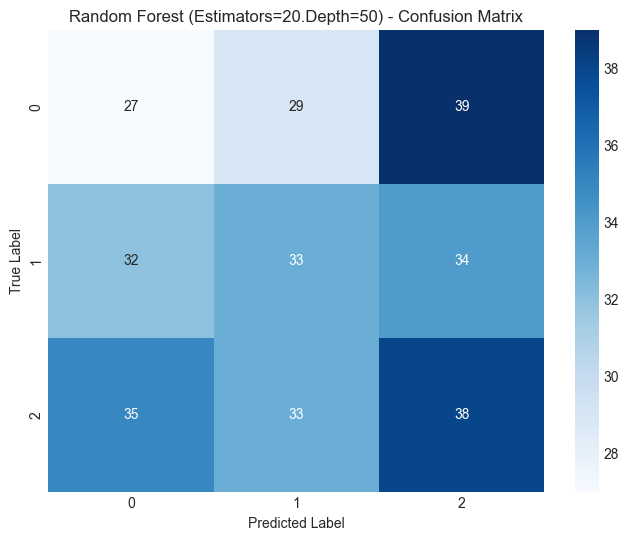

Accuracy: 0.3267
Sensitivity (Macro Recall): 0.3253
Specificity (Macro Specificity): 0.6628
F1 Score: 0.3254

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.28      0.29        95
           1       0.35      0.33      0.34        99
           2       0.34      0.36      0.35       106

    accuracy                           0.33       300
   macro avg       0.33      0.33      0.33       300
weighted avg       0.33      0.33      0.33       300

Feature Importance:
 - Current Temperature (°C): 6.1312123736215955
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.604605792500859
 - PID Control Output (%): 6.156974709065227
 - Fuzzy PID Control Output (%): 6.272551983908644
 - Overshoot (°C): 6.01658406022759
 - Response Time (s): 7.087287784253893
 - Steady-State Error (°C): 5.055698860650727
 - Ambient Temperature (°C): 6.12106141318214
 - Humidity (%): 7.320643745259766
 - PID Kp: 6.302194146450543
 - PID Ki:

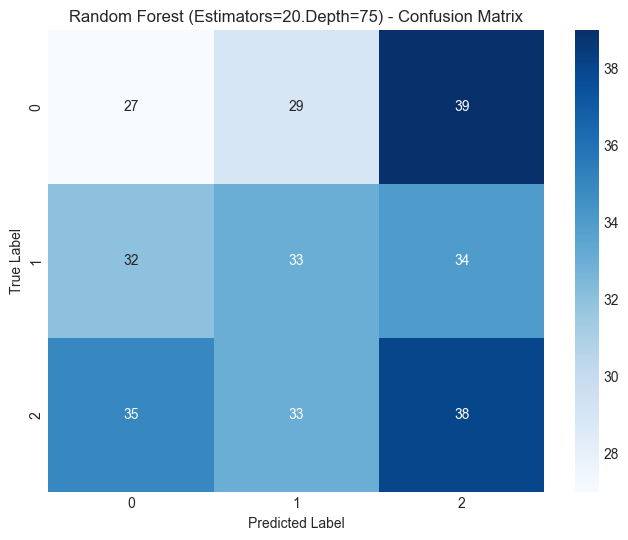

Accuracy: 0.3267
Sensitivity (Macro Recall): 0.3253
Specificity (Macro Specificity): 0.6628
F1 Score: 0.3254

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.28      0.29        95
           1       0.35      0.33      0.34        99
           2       0.34      0.36      0.35       106

    accuracy                           0.33       300
   macro avg       0.33      0.33      0.33       300
weighted avg       0.33      0.33      0.33       300

Feature Importance:
 - Current Temperature (°C): 6.1312123736215955
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.604605792500859
 - PID Control Output (%): 6.156974709065227
 - Fuzzy PID Control Output (%): 6.272551983908644
 - Overshoot (°C): 6.01658406022759
 - Response Time (s): 7.087287784253893
 - Steady-State Error (°C): 5.055698860650727
 - Ambient Temperature (°C): 6.12106141318214
 - Humidity (%): 7.320643745259766
 - PID Kp: 6.302194146450543
 - PID Ki:

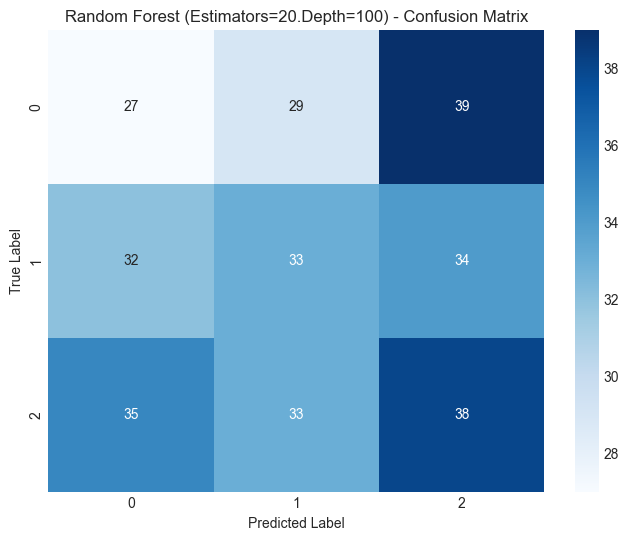

Accuracy: 0.3267
Sensitivity (Macro Recall): 0.3253
Specificity (Macro Specificity): 0.6628
F1 Score: 0.3254

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.28      0.29        95
           1       0.35      0.33      0.34        99
           2       0.34      0.36      0.35       106

    accuracy                           0.33       300
   macro avg       0.33      0.33      0.33       300
weighted avg       0.33      0.33      0.33       300

Feature Importance:
 - Current Temperature (°C): 6.1312123736215955
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.604605792500859
 - PID Control Output (%): 6.156974709065227
 - Fuzzy PID Control Output (%): 6.272551983908644
 - Overshoot (°C): 6.01658406022759
 - Response Time (s): 7.087287784253893
 - Steady-State Error (°C): 5.055698860650727
 - Ambient Temperature (°C): 6.12106141318214
 - Humidity (%): 7.320643745259766
 - PID Kp: 6.302194146450543
 - PID Ki:

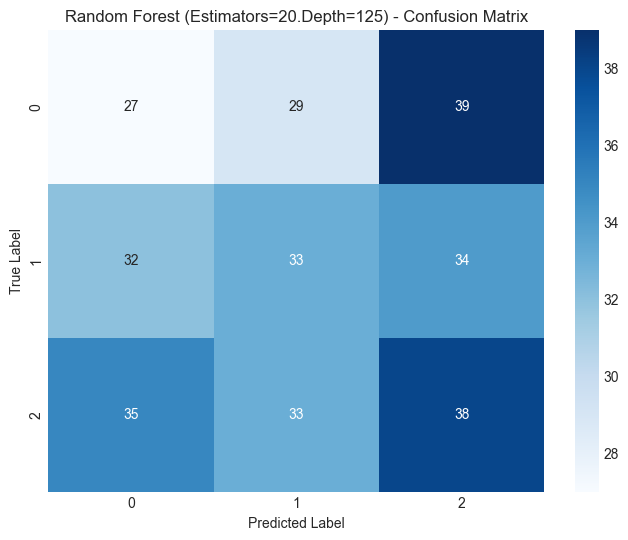

Accuracy: 0.3267
Sensitivity (Macro Recall): 0.3253
Specificity (Macro Specificity): 0.6628
F1 Score: 0.3254

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.28      0.29        95
           1       0.35      0.33      0.34        99
           2       0.34      0.36      0.35       106

    accuracy                           0.33       300
   macro avg       0.33      0.33      0.33       300
weighted avg       0.33      0.33      0.33       300

Feature Importance:
 - Current Temperature (°C): 6.1312123736215955
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.604605792500859
 - PID Control Output (%): 6.156974709065227
 - Fuzzy PID Control Output (%): 6.272551983908644
 - Overshoot (°C): 6.01658406022759
 - Response Time (s): 7.087287784253893
 - Steady-State Error (°C): 5.055698860650727
 - Ambient Temperature (°C): 6.12106141318214
 - Humidity (%): 7.320643745259766
 - PID Kp: 6.302194146450543
 - PID Ki:

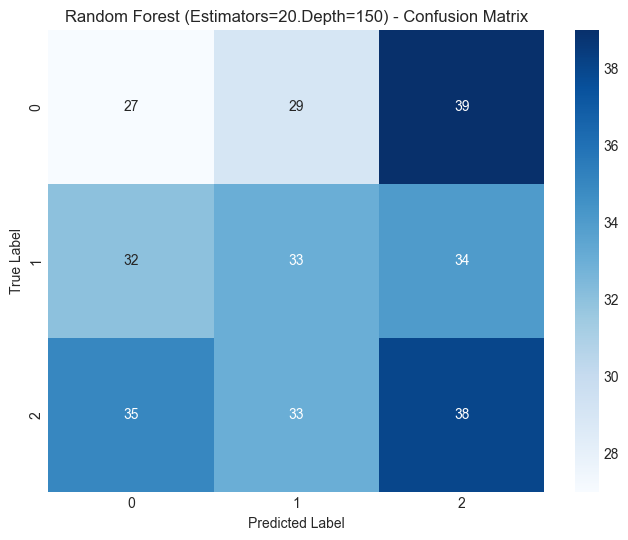

Accuracy: 0.3267
Sensitivity (Macro Recall): 0.3253
Specificity (Macro Specificity): 0.6628
F1 Score: 0.3254

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.28      0.29        95
           1       0.35      0.33      0.34        99
           2       0.34      0.36      0.35       106

    accuracy                           0.33       300
   macro avg       0.33      0.33      0.33       300
weighted avg       0.33      0.33      0.33       300

Feature Importance:
 - Current Temperature (°C): 6.1312123736215955
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.604605792500859
 - PID Control Output (%): 6.156974709065227
 - Fuzzy PID Control Output (%): 6.272551983908644
 - Overshoot (°C): 6.01658406022759
 - Response Time (s): 7.087287784253893
 - Steady-State Error (°C): 5.055698860650727
 - Ambient Temperature (°C): 6.12106141318214
 - Humidity (%): 7.320643745259766
 - PID Kp: 6.302194146450543
 - PID Ki:

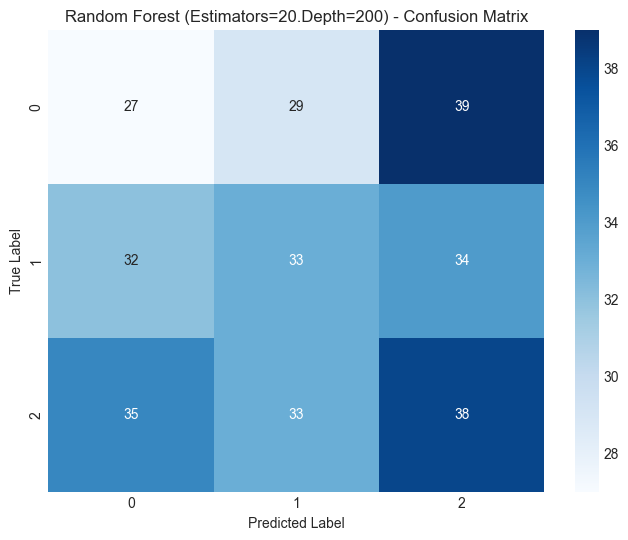

Accuracy: 0.3267
Sensitivity (Macro Recall): 0.3253
Specificity (Macro Specificity): 0.6628
F1 Score: 0.3254

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.28      0.29        95
           1       0.35      0.33      0.34        99
           2       0.34      0.36      0.35       106

    accuracy                           0.33       300
   macro avg       0.33      0.33      0.33       300
weighted avg       0.33      0.33      0.33       300

Feature Importance:
 - Current Temperature (°C): 6.1312123736215955
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.604605792500859
 - PID Control Output (%): 6.156974709065227
 - Fuzzy PID Control Output (%): 6.272551983908644
 - Overshoot (°C): 6.01658406022759
 - Response Time (s): 7.087287784253893
 - Steady-State Error (°C): 5.055698860650727
 - Ambient Temperature (°C): 6.12106141318214
 - Humidity (%): 7.320643745259766
 - PID Kp: 6.302194146450543
 - PID Ki:

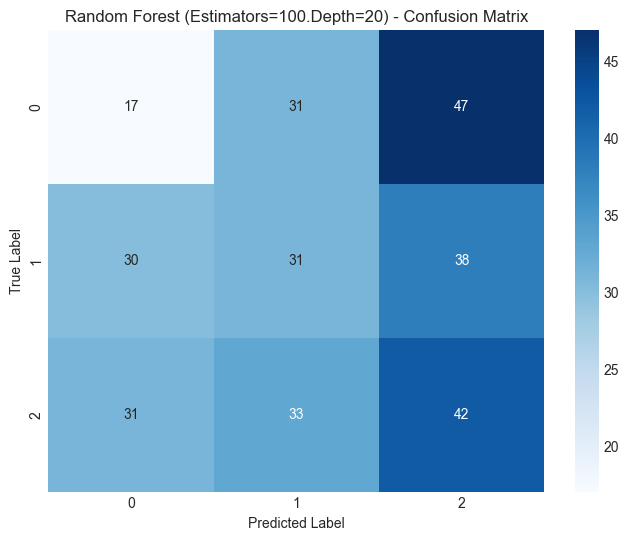

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2961
Specificity (Macro Specificity): 0.6486
F1 Score: 0.2922

Classification Report:
               precision    recall  f1-score   support

           0       0.22      0.18      0.20        95
           1       0.33      0.31      0.32        99
           2       0.33      0.40      0.36       106

    accuracy                           0.30       300
   macro avg       0.29      0.30      0.29       300
weighted avg       0.29      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 5.581836070609786
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.701327953287572
 - PID Control Output (%): 6.398204348244403
 - Fuzzy PID Control Output (%): 5.7539553003517865
 - Overshoot (°C): 5.746746941322771
 - Response Time (s): 6.925226510120877
 - Steady-State Error (°C): 5.503089086040733
 - Ambient Temperature (°C): 7.060326552040709
 - Humidity (%): 7.5473475409336865
 - PID Kp: 6.59514892638812
 - PID K

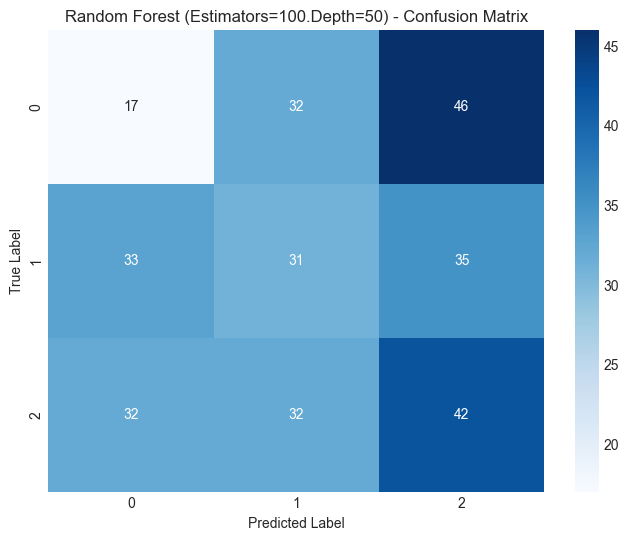

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2961
Specificity (Macro Specificity): 0.6490
F1 Score: 0.2928

Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.18      0.19        95
           1       0.33      0.31      0.32        99
           2       0.34      0.40      0.37       106

    accuracy                           0.30       300
   macro avg       0.29      0.30      0.29       300
weighted avg       0.29      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 5.599854570863432
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.721725635677313
 - PID Control Output (%): 6.321316298061127
 - Fuzzy PID Control Output (%): 5.809389798876355
 - Overshoot (°C): 5.666095553043967
 - Response Time (s): 6.754463337930164
 - Steady-State Error (°C): 5.569757839593871
 - Ambient Temperature (°C): 7.139174749919637
 - Humidity (%): 7.617694277211502
 - PID Kp: 6.567739850927588
 - PID Ki

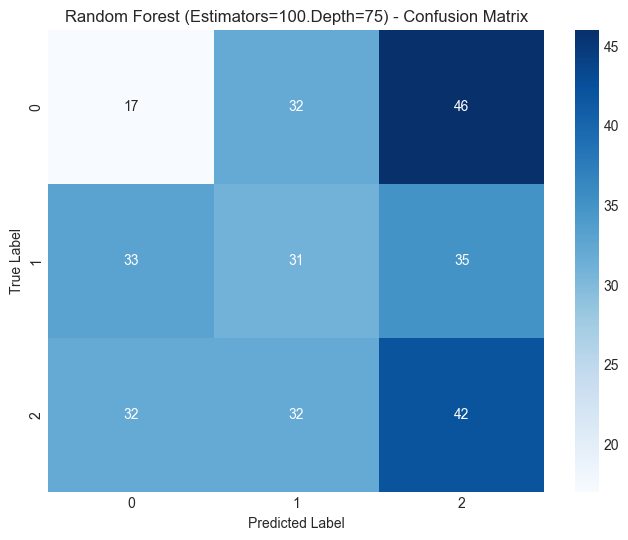

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2961
Specificity (Macro Specificity): 0.6490
F1 Score: 0.2928

Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.18      0.19        95
           1       0.33      0.31      0.32        99
           2       0.34      0.40      0.37       106

    accuracy                           0.30       300
   macro avg       0.29      0.30      0.29       300
weighted avg       0.29      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 5.599854570863432
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.721725635677313
 - PID Control Output (%): 6.321316298061127
 - Fuzzy PID Control Output (%): 5.809389798876355
 - Overshoot (°C): 5.666095553043967
 - Response Time (s): 6.754463337930164
 - Steady-State Error (°C): 5.569757839593871
 - Ambient Temperature (°C): 7.139174749919637
 - Humidity (%): 7.617694277211502
 - PID Kp: 6.567739850927588
 - PID Ki

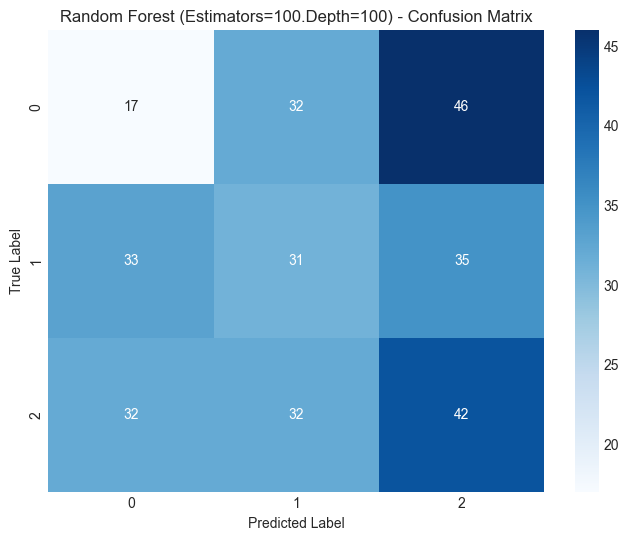

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2961
Specificity (Macro Specificity): 0.6490
F1 Score: 0.2928

Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.18      0.19        95
           1       0.33      0.31      0.32        99
           2       0.34      0.40      0.37       106

    accuracy                           0.30       300
   macro avg       0.29      0.30      0.29       300
weighted avg       0.29      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 5.599854570863432
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.721725635677313
 - PID Control Output (%): 6.321316298061127
 - Fuzzy PID Control Output (%): 5.809389798876355
 - Overshoot (°C): 5.666095553043967
 - Response Time (s): 6.754463337930164
 - Steady-State Error (°C): 5.569757839593871
 - Ambient Temperature (°C): 7.139174749919637
 - Humidity (%): 7.617694277211502
 - PID Kp: 6.567739850927588
 - PID Ki

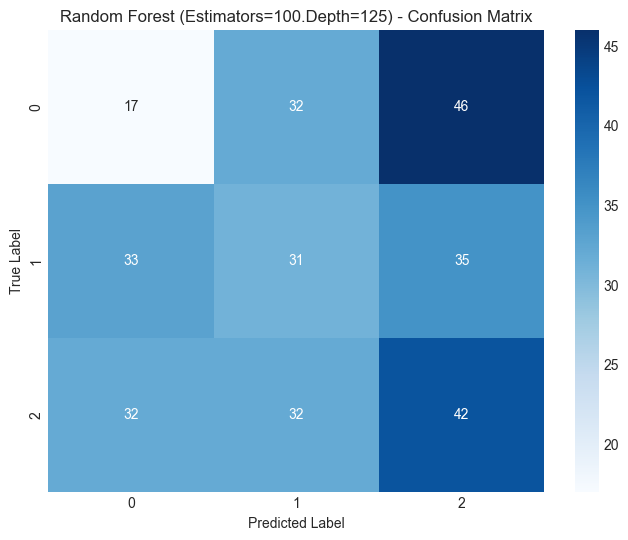

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2961
Specificity (Macro Specificity): 0.6490
F1 Score: 0.2928

Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.18      0.19        95
           1       0.33      0.31      0.32        99
           2       0.34      0.40      0.37       106

    accuracy                           0.30       300
   macro avg       0.29      0.30      0.29       300
weighted avg       0.29      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 5.599854570863432
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.721725635677313
 - PID Control Output (%): 6.321316298061127
 - Fuzzy PID Control Output (%): 5.809389798876355
 - Overshoot (°C): 5.666095553043967
 - Response Time (s): 6.754463337930164
 - Steady-State Error (°C): 5.569757839593871
 - Ambient Temperature (°C): 7.139174749919637
 - Humidity (%): 7.617694277211502
 - PID Kp: 6.567739850927588
 - PID Ki

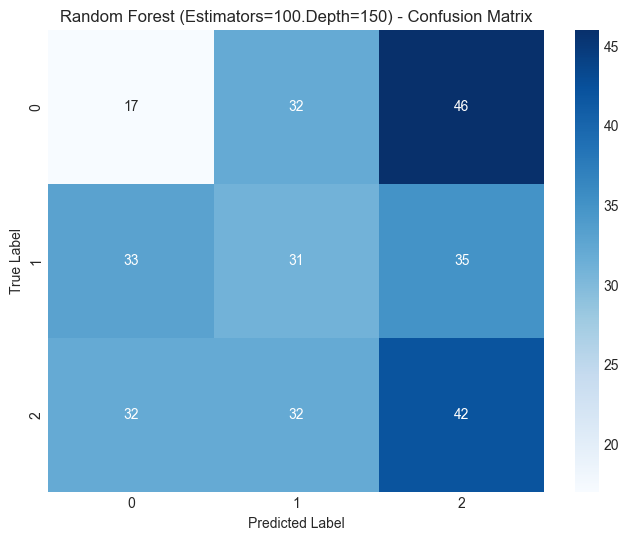

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2961
Specificity (Macro Specificity): 0.6490
F1 Score: 0.2928

Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.18      0.19        95
           1       0.33      0.31      0.32        99
           2       0.34      0.40      0.37       106

    accuracy                           0.30       300
   macro avg       0.29      0.30      0.29       300
weighted avg       0.29      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 5.599854570863432
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.721725635677313
 - PID Control Output (%): 6.321316298061127
 - Fuzzy PID Control Output (%): 5.809389798876355
 - Overshoot (°C): 5.666095553043967
 - Response Time (s): 6.754463337930164
 - Steady-State Error (°C): 5.569757839593871
 - Ambient Temperature (°C): 7.139174749919637
 - Humidity (%): 7.617694277211502
 - PID Kp: 6.567739850927588
 - PID Ki

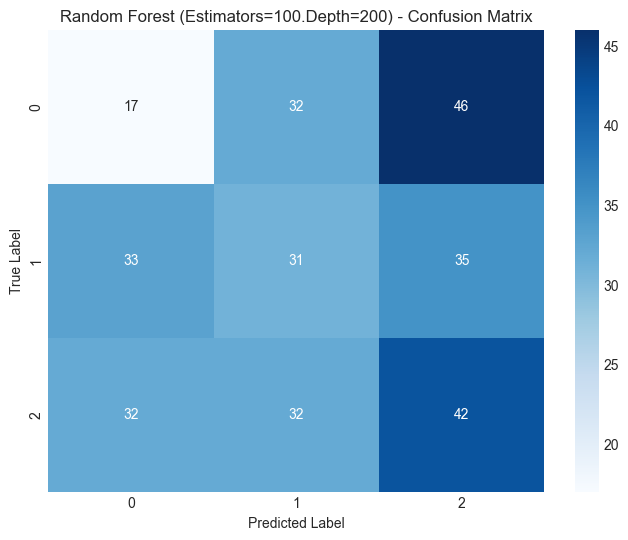

Accuracy: 0.3000
Sensitivity (Macro Recall): 0.2961
Specificity (Macro Specificity): 0.6490
F1 Score: 0.2928

Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.18      0.19        95
           1       0.33      0.31      0.32        99
           2       0.34      0.40      0.37       106

    accuracy                           0.30       300
   macro avg       0.29      0.30      0.29       300
weighted avg       0.29      0.30      0.30       300

Feature Importance:
 - Current Temperature (°C): 5.599854570863432
 - Setpoint Temperature (°C): 0.0
 - Temperature Error (°C): 5.721725635677313
 - PID Control Output (%): 6.321316298061127
 - Fuzzy PID Control Output (%): 5.809389798876355
 - Overshoot (°C): 5.666095553043967
 - Response Time (s): 6.754463337930164
 - Steady-State Error (°C): 5.569757839593871
 - Ambient Temperature (°C): 7.139174749919637
 - Humidity (%): 7.617694277211502
 - PID Kp: 6.567739850927588
 - PID Ki

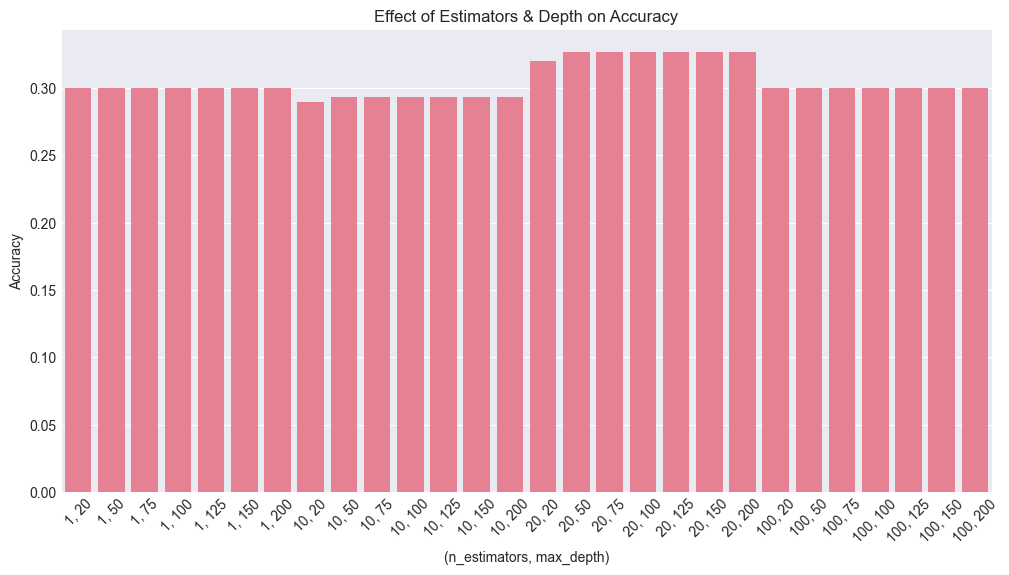

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.preprocessing import LabelEncoder

# Prepare the data
# First, check if we need to encode the target
print("Target variable unique values:", data["Fuzzy Rule Base Parameters"].unique())
print("Target variable counts:")
print(data["Fuzzy Rule Base Parameters"].value_counts(dropna=False))

# Encode the target variable
# Handle NaN values (likely represent PID control)
le = LabelEncoder()
# Create a copy and fill NaN with 'PID'
Y_encoded = data["Fuzzy Rule Base Parameters"].fillna('PID').astype(str)
Y = le.fit_transform(Y_encoded)

print(f"\nEncoding mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {label} -> {i}")

# Prepare features
X = data[['Current Temperature (°C)', 'Setpoint Temperature (°C)',
       'Temperature Error (°C)', 'PID Control Output (%)',
       'Fuzzy PID Control Output (%)', 'Overshoot (°C)', 'Response Time (s)',
       'Steady-State Error (°C)', 'Ambient Temperature (°C)', 'Humidity (%)',
       'PID Kp', 'PID Ki', 'PID Kd', 'Time Seconds', 'Final Temperature (°C)', 'Peak Temperature (°C)',
       'Error Rate (°C)']]

# Check for missing values
print(f"\nMissing values in features:")
print(X.isnull().sum())

# Handle missing values if any
X = X.fillna(X.mean())

print(f"\nData shape: X = {X.shape}, Y = {Y.shape}")
print(f"Classes in Y: {np.unique(Y)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Create and train Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

def train_forest(estimators, depth,X_train_scaled, y_train, X_test_scaled, y_test, class_labels=None):
    # Train Random Forest Classifier
    rf_model = RandomForestClassifier(n_estimators=estimators, max_depth=depth, random_state=42)
    rf_model.fit(X_train_scaled, y_train)

    # Predict on test set
    y_pred = rf_model.predict(X_test_scaled)
    # Compute Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
                xticklabels=class_labels if len(class_labels) > 0 else range(len(conf_matrix)), 
                yticklabels=class_labels if len(class_labels) > 0 else range(len(conf_matrix)))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Random Forest (Estimators={estimators}.Depth={depth}) - Confusion Matrix")
    plt.show()

    # Accuracy Score
    accuracy = accuracy_score(y_test, y_pred)

    # Sensitivity (Recall Macro-Averaged)
    sensitivity = recall_score(y_test, y_pred, average='macro')

    # F1 Score Calculation
    f1 = f1_score(y_test, y_pred, average='macro')

    # Specificity Calculation
    specificity_list = []
    for i in range(len(conf_matrix)):
        tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
        fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_list.append(specificity)
    specificity = np.mean(specificity_list)

    # Print Results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity (Macro Recall): {sensitivity:.4f}")
    print(f"Specificity (Macro Specificity): {specificity:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    print("Feature Importance:")
    for name, score in zip(rf_model.feature_names_in_, rf_model.feature_importances_):
        print(f" - {name}: {score*100}")
    
    return rf_model, accuracy

n_estimators_list = [1, 10, 20, 100]
max_depth_list = [20, 50, 75, 100, 125, 150, 200]
results = {}

for n in n_estimators_list:
    for d in max_depth_list:
        rf_model, accuracy = train_forest(n,d,X_train,y_train,X_test,y_test,le.classes_)
        results[n,d] = accuracy

# Convert results dictionary into a DataFrame
results_df = pd.DataFrame(results.items(), columns=['Params', 'Accuracy'])

# Split the 'Params' column into 'n_estimators' and 'max_depth'
results_df[['n_estimators', 'max_depth']] = pd.DataFrame(results_df['Params'].tolist(), index=results_df.index)

# Drop the original tuple column
results_df.drop(columns=['Params'], inplace=True)

# Plot Accuracy for different models
plt.figure(figsize=(12,6))
sns.barplot(x=results_df['n_estimators'].astype(str) + ", " + results_df['max_depth'].astype(str), 
            y=results_df['Accuracy'])

plt.xticks(rotation=45)
plt.xlabel("(n_estimators, max_depth)")
plt.ylabel("Accuracy")
plt.title("Effect of Estimators & Depth on Accuracy")
plt.show()

In [109]:
data.columns

Index(['Timestamp', 'Current Temperature (°C)', 'Setpoint Temperature (°C)',
       'Temperature Error (°C)', 'PID Control Output (%)',
       'Fuzzy PID Control Output (%)', 'Overshoot (°C)', 'Response Time (s)',
       'Steady-State Error (°C)', 'Ambient Temperature (°C)', 'Humidity (%)',
       'PID Kp', 'PID Ki', 'PID Kd', 'Fuzzy Rule Base Parameters',
       'Time Seconds', 'Final Temperature (°C)', 'Peak Temperature (°C)',
       'Error Rate (°C)'],
      dtype='object')

In [110]:
data.head(10)

,Timestamp,Current Temperature (°C),Setpoint Temperature (°C),Temperature Error (°C),PID Control Output (%),Fuzzy PID Control Output (%),Overshoot (°C),Response Time (s),Steady-State Error (°C),Ambient Temperature (°C),Humidity (%),PID Kp,PID Ki,PID Kd,Fuzzy Rule Base Parameters,Time Seconds,Final Temperature (°C),Peak Temperature (°C),Error Rate (°C)
0,2025-01-31 12:09:12.524887,368.727006,400,31.272994,67.405317,65.022374,6.727030,47.159876,0.787271,23.944771,50.387995,1.220268,0.465431,0.249456,2,0,399.212729,406.727030,NaN
1,2025-01-31 12:14:12.524887,397.535715,400,2.464285,81.676038,79.145826,7.966814,54.162970,0.946871,22.517159,51.867725,1.187283,0.310144,0.233165,0,300,399.053129,407.966814,-28.808709
2,2025-01-31 12:19:12.524887,386.599697,400,13.400303,94.917833,98.980379,2.504679,52.804828,1.709095,24.617184,58.312458,0.595754,0.389964,0.170462,0,600,398.290905,402.504679,10.936018
3,2025-01-31 12:24:12.524887,379.932924,400,20.067076,89.288995,86.784457,6.248741,34.616997,0.680009,23.839349,57.667684,1.422572,0.274419,0.342907,1,900,399.319991,406.248741,6.666773
4,2025-01-31 12:29:12.524887,357.800932,400,42.199068,92.262446,89.981943,5.717460,34.477484,1.739299,22.471612,53.506427,1.068472,0.352014,0.290650,2,1200,398.260701,405.717460,22.131992
5,2025-01-31 12:34:12.524887,357.799726,400,42.200274,86.351335,88.945317,8.328304,38.045231,0.176269,24.887014,53.768106,0.863726,0.236230,0.446280,2,1500,399.823731,408.328304,0.001206
6,2025-01-31 12:39:12.524887,352.904181,400,47.095819,87.691063,87.188461,9.060871,40.832242,1.553597,23.555096,55.335544,1.256539,0.220464,0.112844,2,1800,398.446403,409.060871,4.895545
7,2025-01-31 12:44:12.524887,393.308807,400,6.691193,93.967826,96.734932,0.121568,42.253667,1.695095,22.218695,50.002410,0.757365,0.331292,0.357547,2,2100,398.304905,400.121568,-40.404627
8,2025-01-31 12:49:12.524887,380.055751,400,19.944249,69.986720,65.640382,6.740199,50.390917,0.363635,23.880499,52.412443,1.193510,0.299252,0.405180,2,2400,399.636365,406.740199,13.253057
9,2025-01-31 12:54:12.524887,385.403629,400,14.596371,79.576999,79.452710,0.518358,31.700413,0.860693,22.759597,52.082318,0.539711,0.331815,0.403795,2,2700,399.139307,400.518358,-5.347878


## Summary for part 1
The project is about getting familiar with fuzzy system identification. In this case, it is a first order thermal system with a fixed setpoint of 400 $^\circ C$. Every control cycle takes 300 seconds/ 5 minutes. Input is an electrical current, which generates thermal output to bring the temperature closeest to 400 $^\circ C$. There are 2 types of system in here: fuzzy logic controller (3 rules) and conventional PID controller. All overshoot temperature are positive, which means the PID has fast and aggressive attributes. A case study on a method of auto-tuning the PID so that it matches the target temperature. 